In [1]:
from pathlib import Path

FIGS_ROOT = Path("figs")
PLOT_OUTPUT_DIR = FIGS_ROOT / "prior_analysis"
CONFIG_IDS = ["config_018", "config_013", "config_012", "config_014", "config_015", "config_017"]
PRIORS = ["uniform", "normal", "exponential", "grid"]
LOAD_RAW = True
RAW_MAX_POINTS_PER_CONFIG = 2_000
THREE_D_REFERENCE_THETA = (5.0, 5.0, 5.0)

# Prior Analysis

This notebook compares the clean 1D-6D `toy_example_nD_tidy.py` sweep from the perspective of **prior choice**.

It keeps the same summary artifacts used in `dimensionality_analysis.ipynb`, but flips the presentation:
- priors are the main comparison axis,
- dimensions become the sweep context,
- and dimension-specific panels make it easy to see where each prior helps or hurts.

Notes:
- The default sweep is `config_018, 013, 012, 014, 015, 017`, which resolve to dimensions `1, 2, 3, 4, 5, 6`.
- The fast path uses the saved summary JSON artifacts only.
- The optional raw deep-dive samples compact-store arrays with a lower cap so all six dimensions remain practical.

In [2]:
import warnings

import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib import pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter

from src.dimensionality_analysis import load_dimensionality_summary, load_raw_compact_store

warnings.simplefilter("default")
pd.options.display.max_columns = 80
pd.options.display.float_format = "{:.3f}".format

PRIOR_COLORS = {
    "uniform": "#1f77b4",
    "normal": "#d17a22",
    "exponential": "#2a9d4b",
    "grid": "#7b61ff",
}
PRIOR_MARKERS = {
    "uniform": "o",
    "normal": "s",
    "exponential": "^",
    "grid": "D",
}
PRIOR_LABELS = {prior: prior.title() for prior in PRIOR_COLORS}
DIMENSION_MARKER_SEQUENCE = ["o", "s", "^", "D", "P", "X", "v", "<", ">"]


def normalized_config_ids(config_ids):
    return [config_id if str(config_id).startswith("config_") else f"config_{config_id}" for config_id in config_ids]


def active_priors(dataframe):
    if dataframe is None or getattr(dataframe, "empty", True) or "prior" not in dataframe.columns:
        return list(PRIORS)
    present_priors = set(dataframe["prior"].dropna().astype(str))
    return [prior for prior in PRIORS if prior in present_priors]


def ordered_dimensions(dataframe):
    if dataframe is None or getattr(dataframe, "empty", True) or "dimension" not in dataframe.columns:
        return []
    return sorted(int(value) for value in pd.Series(dataframe["dimension"]).dropna().unique())


def build_dimension_style_maps(dimensions):
    dimensions = list(dimensions)
    color_positions = np.linspace(0.1, 0.9, num=max(len(dimensions), 1))
    colors = {dim: plt.cm.viridis(position) for dim, position in zip(dimensions, color_positions)}
    markers = {
        dim: DIMENSION_MARKER_SEQUENCE[index % len(DIMENSION_MARKER_SEQUENCE)]
        for index, dim in enumerate(dimensions)
    }
    return colors, markers


def build_dimension_legend_handles(dimensions):
    colors, markers = build_dimension_style_maps(dimensions)
    return [
        Line2D(
            [0],
            [0],
            color=colors[dimension],
            marker=markers[dimension],
            linewidth=2,
            label=f"{dimension}D",
        )
        for dimension in dimensions
    ]


def build_prior_legend_handles(priors):
    return [
        Line2D(
            [0],
            [0],
            color=PRIOR_COLORS.get(prior, "gray"),
            marker=PRIOR_MARKERS.get(prior, "o"),
            linewidth=2,
            label=PRIOR_LABELS.get(prior, prior),
        )
        for prior in priors
    ]


def add_shared_colorbar(fig, axes, mappable, label, *, right=0.88, pad=0.02, top=0.9, bottom=0.14, left=0.08, wspace=0.28, hspace=0.25):
    axes_list = np.atleast_1d(axes).ravel().tolist()
    fig.subplots_adjust(left=left, right=right, bottom=bottom, top=top, wspace=wspace, hspace=hspace)
    colorbar = fig.colorbar(mappable, ax=axes_list, fraction=0.035, pad=pad)
    colorbar.set_label(label)
    return colorbar


def save_figure(fig, filename, *, dpi=200):
    PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    output_path = PLOT_OUTPUT_DIR / f"{filename}.pdf"
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    return output_path


def build_compact_metric_table(runs_df):
    columns = [
        "config_id",
        "dimension",
        "prior",
        "pooled_rmse_log_r10",
        "median_rmse_log_r10",
        "worst_rmse_log_r10",
        "median_ess_fraction",
        "median_swd",
        "coverage_68",
        "coverage_gap_68",
        "coverage_95",
        "coverage_gap_95",
        "mean_interval_width_68",
        "mean_interval_width_95",
    ]
    return runs_df[columns].sort_values(["dimension", "prior"]).reset_index(drop=True)


def build_prior_summary(runs_df):
    if runs_df.empty:
        return pd.DataFrame()
    summary = (
        runs_df.groupby("prior")
        .agg(
            mean_pooled_rmse=("pooled_rmse_log_r10", "mean"),
            median_pooled_rmse=("pooled_rmse_log_r10", "median"),
            mean_median_rmse=("median_rmse_log_r10", "mean"),
            mean_worst_rmse=("worst_rmse_log_r10", "mean"),
            mean_median_ess_fraction=("median_ess_fraction", "mean"),
            median_median_ess_fraction=("median_ess_fraction", "median"),
            mean_median_swd=("median_swd", "mean"),
            mean_coverage_68=("coverage_68", "mean"),
            mean_coverage_gap_68=("coverage_gap_68", "mean"),
            mean_coverage_95=("coverage_95", "mean"),
            mean_coverage_gap_95=("coverage_gap_95", "mean"),
            mean_interval_width_68=("mean_interval_width_68", "mean"),
            mean_interval_width_95=("mean_interval_width_95", "mean"),
        )
        .reindex(active_priors(runs_df))
        .reset_index()
    )
    return summary


def build_dimension_winner_table(runs_df):
    if runs_df.empty:
        return pd.DataFrame()
    metric_rules = [
        ("best_pooled_rmse", "pooled_rmse_log_r10", True),
        ("best_median_rmse", "median_rmse_log_r10", True),
        ("best_median_ess_fraction", "median_ess_fraction", False),
        ("best_median_swd", "median_swd", True),
        ("best_coverage_gap_68", "coverage_gap_68", True),
        ("best_coverage_gap_95", "coverage_gap_95", True),
    ]
    rows = []
    for dimension, subset in runs_df.groupby("dimension"):
        row = {"dimension": int(dimension)}
        for label, metric, ascending in metric_rules:
            ranked = subset.sort_values([metric, "prior"], ascending=[ascending, True]).reset_index(drop=True)
            best = ranked.iloc[0]
            row[label] = f"{best['prior']} ({best[metric]:.3f})"
        rows.append(row)
    return pd.DataFrame(rows).sort_values("dimension").reset_index(drop=True)


def build_prior_win_count_table(runs_df):
    if runs_df.empty:
        return pd.DataFrame()
    metric_rules = {
        "pooled_rmse_win": ("pooled_rmse_log_r10", True),
        "median_rmse_win": ("median_rmse_log_r10", True),
        "median_ess_fraction_win": ("median_ess_fraction", False),
        "median_swd_win": ("median_swd", True),
        "coverage_gap_68_win": ("coverage_gap_68", True),
        "coverage_gap_95_win": ("coverage_gap_95", True),
    }
    wins = []
    for dimension, subset in runs_df.groupby("dimension"):
        for win_label, (metric, ascending) in metric_rules.items():
            ranked = subset.sort_values([metric, "prior"], ascending=[ascending, True]).reset_index(drop=True)
            wins.append({
                "dimension": int(dimension),
                "metric": win_label,
                "prior": str(ranked.loc[0, "prior"]),
            })
    wins_df = pd.DataFrame(wins)
    summary = wins_df.pivot_table(index="prior", columns="metric", values="dimension", aggfunc="count", fill_value=0)
    summary = summary.reindex(active_priors(runs_df)).fillna(0).astype(int)
    summary["total_wins"] = summary.sum(axis=1)
    return summary.reset_index()


def build_delta_vs_uniform_table(runs_df):
    if runs_df.empty or "uniform" not in set(runs_df["prior"].astype(str)):
        return pd.DataFrame()
    baseline = runs_df.loc[runs_df["prior"].astype(str) == "uniform"].set_index("dimension")
    rows = []
    for prior in active_priors(runs_df):
        if prior == "uniform":
            continue
        subset = runs_df.loc[runs_df["prior"].astype(str) == prior].set_index("dimension")
        common_dimensions = baseline.index.intersection(subset.index)
        if common_dimensions.empty:
            continue
        base = baseline.loc[common_dimensions]
        comp = subset.loc[common_dimensions]
        rows.append(
            {
                "prior": prior,
                "delta_pooled_rmse": float((comp["pooled_rmse_log_r10"] - base["pooled_rmse_log_r10"]).mean()),
                "delta_median_rmse": float((comp["median_rmse_log_r10"] - base["median_rmse_log_r10"]).mean()),
                "delta_median_ess_fraction": float((comp["median_ess_fraction"] - base["median_ess_fraction"]).mean()),
                "delta_median_swd": float((comp["median_swd"] - base["median_swd"]).mean()),
                "delta_coverage_gap_68": float((comp["coverage_gap_68"] - base["coverage_gap_68"]).mean()),
                "delta_mean_interval_width_68": float((comp["mean_interval_width_68"] - base["mean_interval_width_68"]).mean()),
            }
        )
    return pd.DataFrame(rows).sort_values("delta_pooled_rmse").reset_index(drop=True)


def build_correlation_summary(pairs_df):
    if pairs_df.empty:
        return pd.DataFrame()
    rows = []
    for (dimension, prior), subset in pairs_df.groupby(["dimension", "prior"]):
        rows.append(
            {
                "dimension": int(dimension),
                "prior": str(prior),
                "spearman_rmse_vs_distance": subset["distance"].corr(subset["rmse_log_r10"], method="spearman"),
                "spearman_swd_vs_distance": subset["distance"].corr(subset["swd"], method="spearman"),
                "spearman_ess_fraction_vs_distance": subset["distance"].corr(subset["ess_fraction"], method="spearman"),
            }
        )
    return pd.DataFrame(rows).sort_values(["dimension", "prior"]).reset_index(drop=True)


def build_bias_summary(curves_df):
    if curves_df.empty:
        return pd.DataFrame(columns=["dimension", "prior", "mean_bias", "mean_abs_bias"])
    summary = (
        curves_df.groupby(["dimension", "prior"], observed=False)
        .agg(
            mean_bias=("avg_bias", "mean"),
            mean_abs_bias=("avg_bias", lambda values: values.abs().mean()),
        )
        .reset_index()
        .sort_values(["dimension", "prior"])
        .reset_index(drop=True)
    )
    return summary


def build_map_hld_interval_summary(raw_map_df, raw_intervals_df, interval_level="68"):
    columns = [
        "dimension",
        "prior",
        "mean_bias",
        "mean_abs_bias",
        "mean_upper_map_distance",
        "mean_lower_map_distance",
    ]
    if raw_map_df.empty or raw_intervals_df.empty:
        return pd.DataFrame(columns=columns)
    intervals = raw_intervals_df.loc[
        raw_intervals_df["interval_level"].astype(str) == str(interval_level)
    ].copy()
    if intervals.empty:
        return pd.DataFrame(columns=columns)
    merged = intervals.merge(
        raw_map_df[
            ["config_id", "dimension", "prior", "sample_index", "dim_index", "map_estimate"]
        ],
        on=["config_id", "dimension", "prior", "sample_index", "dim_index"],
        how="inner",
        validate="one_to_one",
    )
    if merged.empty:
        return pd.DataFrame(columns=columns)
    merged["map_bias"] = merged["map_estimate"] - merged["true_value"]
    merged["abs_map_bias"] = merged["map_bias"].abs()
    merged["upper_map_distance"] = merged["high"] - merged["map_estimate"]
    merged["lower_map_distance"] = merged["map_estimate"] - merged["low"]
    summary = (
        merged.groupby(["dimension", "prior"], observed=False)
        .agg(
            mean_bias=("map_bias", "mean"),
            mean_abs_bias=("abs_map_bias", "mean"),
            mean_upper_map_distance=("upper_map_distance", "mean"),
            mean_lower_map_distance=("lower_map_distance", "mean"),
        )
        .reset_index()
        .sort_values(["dimension", "prior"])
        .reset_index(drop=True)
    )
    return summary[columns]


def build_prior_observation_markdown(prior_summary_df, prior_win_count_df, delta_vs_uniform_df):
    if prior_summary_df.empty:
        return Markdown("No prior summary was loaded.")

    best_rmse = prior_summary_df.loc[prior_summary_df["mean_pooled_rmse"].idxmin()]
    best_ess = prior_summary_df.loc[prior_summary_df["mean_median_ess_fraction"].idxmax()]
    best_cal = prior_summary_df.loc[prior_summary_df["mean_coverage_gap_68"].idxmin()]

    lines = ["### Prior-focused interpretation"]
    lines.append(
        f"- **{PRIOR_LABELS.get(best_rmse['prior'], best_rmse['prior'])}** has the lowest mean pooled RMSE across the 1D-6D sweep (**{best_rmse['mean_pooled_rmse']:.3f}**)."
    )
    lines.append(
        f"- **{PRIOR_LABELS.get(best_ess['prior'], best_ess['prior'])}** has the largest average median ESS fraction (**{best_ess['mean_median_ess_fraction']:.3f}**), so it tends to preserve the strongest reweighting support."
    )
    lines.append(
        f"- **{PRIOR_LABELS.get(best_cal['prior'], best_cal['prior'])}** is closest to nominal 68% coverage on average, with a mean absolute coverage gap of **{best_cal['mean_coverage_gap_68']:.3f}**."
    )

    if not prior_win_count_df.empty:
        win_leader = prior_win_count_df.sort_values(["total_wins", "prior"], ascending=[False, True]).iloc[0]
        lines.append(
            f"- In the dimension-by-dimension win table, **{PRIOR_LABELS.get(win_leader['prior'], win_leader['prior'])}** collects the most metric wins (**{int(win_leader['total_wins'])}** total)."
        )

    if delta_vs_uniform_df is not None and not delta_vs_uniform_df.empty:
        strongest_rmse_delta = delta_vs_uniform_df.sort_values(["delta_pooled_rmse", "prior"]).iloc[0]
        if strongest_rmse_delta["delta_pooled_rmse"] < 0:
            lines.append(
                f"- Relative to the uniform baseline, **{PRIOR_LABELS.get(strongest_rmse_delta['prior'], strongest_rmse_delta['prior'])}** yields the strongest mean pooled-RMSE improvement (**{strongest_rmse_delta['delta_pooled_rmse']:.3f}**)."
            )

    return Markdown("\n".join(lines))


def plot_metric_vs_prior(ax, data, metric, title, ylabel, *, logy=False, nominal=None, connect_points=True, marker_size=7, marker_alpha=1.0, line_alpha=1.0, line_style=None, line_width=2):
    priors = active_priors(data)
    dimensions = ordered_dimensions(data)
    x_positions = np.arange(len(priors))
    colors, markers = build_dimension_style_maps(dimensions)
    for dimension in dimensions:
        subset = data.loc[data["dimension"] == dimension].copy()
        if subset.empty:
            continue
        subset["prior"] = subset["prior"].astype(str)
        subset = subset.set_index("prior").reindex(priors).reset_index()
        if connect_points:
            ax.plot(
                x_positions,
                subset[metric],
                color=colors[dimension],
                linestyle=line_style if line_style is not None else "-",
                linewidth=line_width,
                alpha=line_alpha,
                zorder=1,
            )
        ax.plot(
            x_positions,
            subset[metric],
            color=colors[dimension],
            marker=markers[dimension],
            linestyle="none",
            markersize=marker_size,
            alpha=marker_alpha,
            markeredgewidth=0.9,
            label=f"{dimension}D",
            zorder=2,
        )
    if nominal is not None:
        ax.axhline(nominal, color="black", linestyle="--", linewidth=1.4, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Prior")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors], rotation=20)
    ax.grid(alpha=0.3)
    if logy:
        ax.set_yscale("log")


def plot_metric_by_dimension_panels(data, metric, title_prefix, ylabel, *, nominal=None, logy=False, figsize=(16, 8), sharey=True):
    dimensions = ordered_dimensions(data)
    priors = active_priors(data)
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, sharey=sharey, squeeze=False)
    axes = axes.ravel()
    x_positions = np.arange(len(priors))
    for ax, dimension in zip(axes, dimensions):
        subset = data.loc[data["dimension"] == dimension].copy()
        subset["prior"] = subset["prior"].astype(str)
        subset = subset.set_index("prior").reindex(priors).reset_index()
        values = subset[metric].to_numpy(dtype=float)
        ax.plot(x_positions, values, color="0.35", linewidth=1.6, alpha=0.85)
        ax.scatter(
            x_positions,
            values,
            s=85,
            c=[PRIOR_COLORS.get(prior, "gray") for prior in priors],
            marker="o",
            edgecolor="black",
            linewidth=0.6,
            zorder=3,
        )
        if nominal is not None:
            ax.axhline(nominal, color="black", linestyle="--", linewidth=1.2, alpha=0.8)
        ax.set_title(f"{dimension}D")
        ax.set_xticks(x_positions)
        ax.set_xticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors], rotation=20)
        ax.grid(alpha=0.25)
        if logy:
            ax.set_yscale("log")
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    for ax in axes[::3]:
        ax.set_ylabel(ylabel)
    for ax in axes[-3:]:
        ax.set_xlabel("Prior")
    legend_handles = build_prior_legend_handles(priors)
    if legend_handles:
        fig.legend(handles=legend_handles, loc="upper center", ncol=min(len(legend_handles), 4), frameon=False)
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    return fig


def build_metric_matrix(data, metric):
    dimensions = ordered_dimensions(data)
    priors = active_priors(data)
    if data is None or metric not in getattr(data, "columns", []) or not dimensions or not priors:
        return pd.DataFrame(index=pd.Index(dimensions, name="dimension"), columns=priors, dtype=float)
    subset = data[["dimension", "prior", metric]].copy()
    subset["prior"] = subset["prior"].astype(str)
    matrix = subset.pivot_table(index="dimension", columns="prior", values=metric, aggfunc="mean")
    matrix = matrix.reindex(index=dimensions, columns=priors)
    matrix.index.name = "dimension"
    matrix.columns.name = "prior"
    return matrix


def plot_metric_heatmap(ax, data, metric, title, colorbar_label, *, cmap, center=None, annotate=False, fmt=".2f"):
    matrix = build_metric_matrix(data, metric)
    priors = list(matrix.columns)
    dimensions = list(matrix.index)
    if not priors or not dimensions:
        image = ax.imshow(np.zeros((1, 1)), aspect="auto", cmap=cmap)
        image.colorbar_label = colorbar_label
        ax.set_axis_off()
        return image
    values = matrix.to_numpy(dtype=float)
    finite_values = values[np.isfinite(values)]
    if finite_values.size:
        if center is None:
            vmin = float(finite_values.min())
            vmax = float(finite_values.max())
        else:
            span = float(np.nanmax(np.abs(finite_values - center)))
            vmin = float(center - span)
            vmax = float(center + span)
    else:
        vmin = None
        vmax = None
    image = ax.imshow(np.ma.masked_invalid(values), aspect="auto", cmap=cmap, vmin=vmin, vmax=vmax)
    image.colorbar_label = colorbar_label
    ax.set_title(title)
    ax.set_xlabel("Prior")
    ax.set_ylabel("Dimension")
    ax.set_xticks(np.arange(len(priors)))
    ax.set_xticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors], rotation=20)
    ax.set_yticks(np.arange(len(dimensions)))
    ax.set_yticklabels([f"{dimension}D" for dimension in dimensions])
    ax.set_xticks(np.arange(-0.5, len(priors), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(dimensions), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.2)
    ax.tick_params(which="minor", bottom=False, left=False)
    if annotate and finite_values.size:
        for row, dimension in enumerate(dimensions):
            for column, prior in enumerate(priors):
                value = matrix.loc[dimension, prior]
                if pd.isna(value):
                    continue
                rgba = image.cmap(image.norm(value))
                luminance = 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]
                text_color = "white" if luminance < 0.5 else "black"
                ax.text(column, row, format(value, fmt), ha="center", va="center", color=text_color, fontsize=9)
    return image


def plot_metric_vs_dimension(ax, data, metric, title, ylabel, *, nominal=None):
    dimensions = ordered_dimensions(data)
    priors = active_priors(data)
    x_positions = np.arange(len(dimensions))
    for prior in priors:
        subset = data.loc[data["prior"].astype(str) == prior, ["dimension", metric]].copy()
        subset = subset.set_index("dimension").reindex(dimensions).reset_index()
        ax.plot(
            x_positions,
            subset[metric],
            color=PRIOR_COLORS.get(prior, "gray"),
            marker=PRIOR_MARKERS.get(prior, "o"),
            linewidth=2,
            markersize=7,
            label=PRIOR_LABELS.get(prior, prior),
        )
    if nominal is not None:
        ax.axhline(nominal, color="black", linestyle="--", linewidth=1.4, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("Dimension")
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_positions)
    ax.set_xticklabels([f"{dimension}D" for dimension in dimensions])
    ax.grid(alpha=0.3)


def plot_prior_facet_metric_grid(pairs_df):
    priors = active_priors(pairs_df)
    metrics = [
        ("rmse_log_r10", "RMSE log10 ratio"),
        ("swd", "Sliced Wasserstein distance"),
        ("ess_fraction", "ESS fraction"),
    ]
    fig, axes = plt.subplots(len(metrics), len(priors), figsize=(4.4 * len(priors), 3.5 * len(metrics)), sharex="col", sharey="row", squeeze=False)
    scatter = None
    for column, prior in enumerate(priors):
        prior_subset = pairs_df.loc[pairs_df["prior"].astype(str) == prior]
        for row, (metric, ylabel) in enumerate(metrics):
            ax = axes[row, column]
            scatter = ax.scatter(
                prior_subset["distance"],
                prior_subset[metric],
                c=prior_subset["dimension"],
                cmap="viridis",
                s=34,
                alpha=0.72,
                edgecolor="none",
            )
            if row == 0:
                ax.set_title(PRIOR_LABELS.get(prior, prior))
            if column == 0:
                ax.set_ylabel(ylabel)
            if row == len(metrics) - 1:
                ax.set_xlabel("Parameter-pair distance")
            ax.grid(alpha=0.22)
    if scatter is not None:
        add_shared_colorbar(fig, axes, scatter, "Dimension", right=0.9, pad=0.02, top=0.92, bottom=0.12, left=0.06, wspace=0.2, hspace=0.28)
    else:
        fig.subplots_adjust(left=0.06, right=0.98, bottom=0.12, top=0.92, wspace=0.2, hspace=0.28)
    return fig


def plot_curve_by_dimension(curves_df, metric, ylabel, title_prefix, *, figsize=(16, 8)):
    dimensions = ordered_dimensions(curves_df)
    priors = active_priors(curves_df)
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax, dimension in zip(axes, dimensions):
        subset = curves_df.loc[curves_df["dimension"] == dimension]
        for prior in priors:
            curve = subset.loc[subset["prior"].astype(str) == prior].sort_values("x_value")
            if curve.empty:
                continue
            ax.plot(
                curve["x_value"],
                curve[metric],
                color=PRIOR_COLORS.get(prior),
                marker=PRIOR_MARKERS.get(prior, "o"),
                linewidth=2,
                markersize=4,
                label=PRIOR_LABELS.get(prior, prior),
            )
        ax.set_title(f"{dimension}D")
        ax.set_xlabel("True value")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.25)
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    legend_handles = build_prior_legend_handles(priors)
    if legend_handles:
        fig.legend(handles=legend_handles, loc="upper center", ncol=min(len(legend_handles), 4), frameon=False)
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    return fig


def plot_curve_heatmaps_by_dimension(curves_df, metric, colorbar_label, cmap):
    dimensions = ordered_dimensions(curves_df)
    priors = active_priors(curves_df)
    fig, axes = plt.subplots(2, 3, figsize=(16, 8), squeeze=False)
    axes = axes.ravel()
    metric_values = curves_df[metric].to_numpy(dtype=float) if metric in curves_df else np.asarray([], dtype=float)
    finite_values = metric_values[np.isfinite(metric_values)]
    vmin = float(finite_values.min()) if finite_values.size else None
    vmax = float(finite_values.max()) if finite_values.size else None
    images = []
    for ax, dimension in zip(axes, dimensions):
        subset = curves_df.loc[curves_df["dimension"] == dimension]
        heatmap = subset.pivot_table(index="prior", columns="x_value", values=metric, aggfunc="mean")
        heatmap = heatmap.reindex(priors)
        masked_values = np.ma.masked_invalid(heatmap.to_numpy(dtype=float))
        image = ax.imshow(masked_values, aspect="auto", origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
        images.append(image)
        ax.set_title(f"{dimension}D")
        ax.set_xlabel("True value")
        ax.set_ylabel("Prior")
        x_positions = np.linspace(0, len(heatmap.columns) - 1, num=min(5, len(heatmap.columns)), dtype=int)
        ax.set_xticks(x_positions)
        ax.set_xticklabels([f"{heatmap.columns[pos]:.1f}" for pos in x_positions])
        ax.set_yticks(np.arange(len(priors)))
        ax.set_yticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors])
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    if images:
        add_shared_colorbar(fig, axes, images[0], colorbar_label, right=0.9, pad=0.03, top=0.9, bottom=0.12, left=0.08, wspace=0.28, hspace=0.32)
    else:
        fig.subplots_adjust(left=0.08, right=0.98, bottom=0.12, top=0.9, wspace=0.28, hspace=0.32)
    return fig


def plot_raw_boxplots_by_dimension(raw_df, value_col, ylabel, title_prefix, *, add_zero_line=False, figsize=(16, 8)):
    dimensions = ordered_dimensions(raw_df)
    priors = active_priors(raw_df)
    fig, axes = plt.subplots(2, 3, figsize=figsize, sharex=True, sharey=True, squeeze=False)
    axes = axes.ravel()
    for ax, dimension in zip(axes, dimensions):
        subset = raw_df.loc[raw_df["dimension"] == dimension]
        box_data = [
            subset.loc[subset["prior"].astype(str) == prior, value_col].to_numpy(dtype=float)
            for prior in priors
        ]
        boxplot = ax.boxplot(
            box_data,
            labels=[PRIOR_LABELS.get(prior, prior) for prior in priors],
            patch_artist=True,
            showfliers=False,
        )
        for patch, prior in zip(boxplot["boxes"], priors):
            patch.set_facecolor(PRIOR_COLORS.get(prior, "gray"))
            patch.set_alpha(0.6)
        for median in boxplot["medians"]:
            median.set_color("black")
            median.set_linewidth(1.4)
        if add_zero_line:
            ax.axhline(0.0, color="black", linestyle="--", linewidth=1.1, alpha=0.8)
        ax.set_title(f"{dimension}D")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.22)
        for label in ax.get_xticklabels():
            label.set_rotation(20)
    for ax in axes[len(dimensions):]:
        ax.set_axis_off()
    fig.suptitle(title_prefix, y=1.02)
    fig.tight_layout()
    return fig

In [3]:
import json
import pickle

import torch

from src.models import BinaryClassifier
from src.verification import compute_ratio


def resolve_three_d_config_id(config_overview_df):
    if config_overview_df is None or getattr(config_overview_df, "empty", True):
        return None
    matches = (
        config_overview_df.loc[pd.Series(config_overview_df["dimension"]).astype(int) == 3, "config_id"]
        .astype(str)
        .tolist()
    )
    return matches[0] if matches else None


def load_three_d_ratio_artifacts(figs_root, config_id):
    if config_id is None:
        return None
    config_dir = Path(figs_root) / str(config_id)
    config_path = config_dir / "config.json"
    payload_path = config_dir / "posterior_errors" / "results_data.pkl"
    if not config_path.exists() or not payload_path.exists():
        return None
    with config_path.open("r", encoding="utf-8") as handle:
        config = json.load(handle)
    with payload_path.open("rb") as handle:
        payload = pickle.load(handle)
    if int(payload.get("n_dimensions", config["data"]["n_parameters"])) != 3:
        return None
    theta_axes, parameter_combinations, sampled_data = payload["inference_data"]
    return {
        "config": config,
        "config_dir": config_dir,
        "theta_axes": tuple(np.asarray(axis, dtype=np.float32) for axis in theta_axes),
        "parameter_combinations": np.asarray(parameter_combinations, dtype=np.float32),
        "sampled_data": np.asarray(sampled_data, dtype=np.float32),
    }


def find_reference_parameter_index(parameter_combinations, reference_theta, *, atol=1e-6):
    reference_theta = np.asarray(reference_theta, dtype=np.float32).reshape(1, -1)
    matches = np.where(
        np.all(np.isclose(np.asarray(parameter_combinations, dtype=np.float32), reference_theta, atol=atol), axis=1)
    )[0]
    return None if matches.size == 0 else int(matches[0])


def get_three_d_prior_model_path(three_d_artifacts, prior):
    return three_d_artifacts["config_dir"] / "models" / "models_0" / f"model_{prior}_prior.pth"


def load_three_d_prior_model(config, model_path):
    model = BinaryClassifier(config)
    state_dict = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state_dict)
    model.eval()
    return model


def stable_logsumexp(log_values, axis=None):
    log_values = np.asarray(log_values, dtype=float)
    max_values = np.max(log_values, axis=axis, keepdims=True)
    summed = np.sum(np.exp(log_values - max_values), axis=axis, keepdims=True)
    result = np.log(np.clip(summed, 1e-300, None)) + max_values
    if axis is None:
        return float(np.squeeze(result))
    return np.squeeze(result, axis=axis)


def evaluate_three_d_joint_log_ratio_surface(model, reference_data, parameter_combinations, theta_shape):
    reference_data = np.asarray(reference_data, dtype=np.float32)
    parameter_combinations = np.asarray(parameter_combinations, dtype=np.float32)
    joint_log_ratio = np.zeros(parameter_combinations.shape[0], dtype=float)
    for observation in reference_data:
        tiled_observation = np.repeat(observation.reshape(1, -1), parameter_combinations.shape[0], axis=0)
        ratio_values, _ = compute_ratio(tiled_observation, parameter_combinations, model, "cpu")
        joint_log_ratio += np.log(np.clip(np.asarray(ratio_values, dtype=float), 1e-300, None))
    return joint_log_ratio.reshape(tuple(int(length) for length in theta_shape))


def normalize_corner_diagonal(log_marginal):
    weights = np.exp(np.asarray(log_marginal, dtype=float) - stable_logsumexp(log_marginal))
    total = float(np.sum(weights))
    if not np.isfinite(total) or total <= 0.0:
        return np.zeros_like(weights)
    return weights / total


def compute_discrete_hld_interval(axis_values, probabilities, mass):
    axis_values = np.asarray(axis_values, dtype=float).ravel()
    probabilities = np.asarray(probabilities, dtype=float).ravel()
    if axis_values.shape != probabilities.shape:
        raise ValueError(
            f"axis_values and probabilities must have matching shapes, got {axis_values.shape} and {probabilities.shape}."
        )
    total = float(np.sum(probabilities))
    if not np.isfinite(total) or total <= 0.0:
        return float(axis_values.min()), float(axis_values.max())
    normalized = probabilities / total
    ordering = np.argsort(normalized)[::-1]
    selected = np.zeros_like(normalized, dtype=bool)
    cumulative = 0.0
    for index in ordering:
        selected[index] = True
        cumulative += float(normalized[index])
        if cumulative >= float(mass):
            break
    interval_axis = axis_values[selected]
    return float(interval_axis.min()), float(interval_axis.max())


def normalize_corner_contour(log_marginal):
    shifted = np.exp(np.asarray(log_marginal, dtype=float) - np.max(log_marginal))
    peak = float(np.max(shifted))
    if not np.isfinite(peak) or peak <= 0.0:
        return np.zeros_like(shifted)
    return shifted / peak


def build_three_d_corner_marginals(joint_log_ratio):
    joint_log_ratio = np.asarray(joint_log_ratio, dtype=float)
    if joint_log_ratio.ndim != 3:
        raise ValueError(f"Expected a 3D joint log-ratio surface, got shape {joint_log_ratio.shape}.")

    diagonal = {}
    contours = {}
    for axis in range(3):
        summed_axes = tuple(index for index in range(3) if index != axis)
        diagonal[axis] = normalize_corner_diagonal(stable_logsumexp(joint_log_ratio, axis=summed_axes))
    for row in range(1, 3):
        for col in range(row):
            remaining_axis = tuple(index for index in range(3) if index not in (col, row))
            pair_log = stable_logsumexp(joint_log_ratio, axis=remaining_axis)
            contours[(row, col)] = normalize_corner_contour(pair_log).T
    return diagonal, contours


def plot_three_d_likelihood_ratio_corner(theta_axes, reference_theta, joint_log_ratio, prior):
    diagonal, contours = build_three_d_corner_marginals(joint_log_ratio)
    mle_multi_index = np.unravel_index(int(np.argmax(joint_log_ratio)), np.asarray(joint_log_ratio).shape)
    mle_theta = tuple(
        float(np.asarray(theta_axes[axis], dtype=float)[mle_multi_index[axis]])
        for axis in range(3)
    )
    fig, axes = plt.subplots(3, 3, figsize=(10, 10), squeeze=False)
    contour_artist = None
    title_fontsize = 18
    axis_label_fontsize = 16
    tick_labelsize = 13
    legend_fontsize = 13
    legend_title_fontsize = 14
    suptitle_fontsize = 19
    colorbar_label_fontsize = 15
    colorbar_tick_labelsize = 12
    interval_handles = [
        Patch(facecolor=PRIOR_COLORS.get(prior, "black"), alpha=0.14, edgecolor="none", label="95% HLD"),
        Patch(facecolor=PRIOR_COLORS.get(prior, "black"), alpha=0.24, edgecolor="none", label="68% HLD"),
        Line2D(
            [0],
            [0],
            color="#c1121f",
            marker="*",
            linestyle="-.",
            linewidth=1.8,
            markersize=11,
            label="MLE",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            linestyle="--",
            linewidth=1.8,
            label=r"True $\theta$",
        ),
    ]
    filled_levels = np.linspace(0.0, 1.0, 12)
    line_levels = np.linspace(0.2, 1.0, 5)

    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            if row < col:
                ax.set_axis_off()
                continue

            x_label = rf"$\theta_{col}$"
            if row == col:
                x_axis = np.asarray(theta_axes[col], dtype=float)
                interval_95 = compute_discrete_hld_interval(x_axis, diagonal[col], 0.95)
                interval_68 = compute_discrete_hld_interval(x_axis, diagonal[col], 0.68)
                ax.axvspan(
                    interval_95[0],
                    interval_95[1],
                    color=PRIOR_COLORS.get(prior, "black"),
                    alpha=0.14,
                    zorder=0,
                )
                ax.axvspan(
                    interval_68[0],
                    interval_68[1],
                    color=PRIOR_COLORS.get(prior, "black"),
                    alpha=0.24,
                    zorder=0,
                )
                ax.plot(
                    x_axis,
                    diagonal[col],
                    color=PRIOR_COLORS.get(prior, "black"),
                    linewidth=2.3,
                )
                ax.axvline(float(reference_theta[col]), color="black", linestyle="--", linewidth=1.2, alpha=0.8)
                ax.axvline(mle_theta[col], color="#c1121f", linestyle="-.", linewidth=1.8, alpha=0.95)
                ax.set_xlim(float(x_axis.min()), float(x_axis.max()))
                ax.set_title(rf"$\theta_{col}$", fontsize=title_fontsize)
                ax.grid(alpha=0.2)
                ax.tick_params(axis="both", labelsize=tick_labelsize)
                if col == 0:
                    ax.set_ylabel("Marginal probability", fontsize=axis_label_fontsize)
                else:
                    ax.tick_params(axis="y", labelleft=False)
                if row == 2:
                    ax.set_xlabel(x_label, fontsize=axis_label_fontsize)
                else:
                    ax.tick_params(axis="x", labelbottom=False)
            else:
                x_axis = np.asarray(theta_axes[col], dtype=float)
                y_axis = np.asarray(theta_axes[row], dtype=float)
                x_grid, y_grid = np.meshgrid(x_axis, y_axis, indexing="xy")
                density = contours[(row, col)]
                contour_artist = ax.contourf(x_grid, y_grid, density, levels=filled_levels, cmap="viridis")
                ax.contour(x_grid, y_grid, density, levels=line_levels, colors="black", linewidths=0.6, alpha=0.5)
                ax.axvline(float(reference_theta[col]), color="black", linestyle="--", linewidth=1.2, alpha=0.75)
                ax.axhline(float(reference_theta[row]), color="black", linestyle="--", linewidth=1.2, alpha=0.75)
                ax.scatter(
                    [mle_theta[col]],
                    [mle_theta[row]],
                    color="#c1121f",
                    edgecolor="white",
                    linewidth=0.8,
                    marker="*",
                    s=150,
                    zorder=6,
                )
                ax.grid(alpha=0.2)
                ax.tick_params(axis="both", labelsize=tick_labelsize)
                if col == 0:
                    ax.set_ylabel(rf"$\theta_{row}$", fontsize=axis_label_fontsize)
                else:
                    ax.tick_params(axis="y", labelleft=False)
                if row == 2:
                    ax.set_xlabel(x_label, fontsize=axis_label_fontsize)
                else:
                    ax.tick_params(axis="x", labelbottom=False)

    axes[0, 2].legend(
        handles=interval_handles,
        loc="center",
        frameon=False,
        title="HLD bands",
        fontsize=legend_fontsize,
        title_fontsize=legend_title_fontsize,
    )
    fig.suptitle(
        f"3D likelihood-ratio corner plot: {PRIOR_LABELS.get(prior, prior)}\n"
        f"True $\\theta$ = {tuple(float(value) for value in reference_theta)}",
        y=0.98,
        fontsize=suptitle_fontsize,
    )
    fig.subplots_adjust(left=0.09, right=0.84, bottom=0.09, top=0.88, wspace=0.24, hspace=0.20)
    if contour_artist is not None:
        colorbar_ax = fig.add_axes([0.87, 0.14, 0.025, 0.46])
        colorbar = fig.colorbar(contour_artist, cax=colorbar_ax, ticks=np.linspace(0.0, 1.0, 6))
        colorbar.set_label("Relative density", fontsize=colorbar_label_fontsize)
        colorbar.ax.tick_params(labelsize=colorbar_tick_labelsize)
        colorbar.ax.yaxis.set_major_formatter(FormatStrFormatter("%.2f"))
    return fig


In [4]:
PLOT_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

requested_config_ids = normalized_config_ids(CONFIG_IDS)
summary_payload = load_dimensionality_summary(FIGS_ROOT, CONFIG_IDS, PRIORS)

config_overview_df = summary_payload["config_overview_df"]
runs_df = summary_payload["runs_df"].copy()
pairs_df = summary_payload["pairs_df"].copy()
curves_df = summary_payload["curves_df"].copy()
resolved_config_ids = summary_payload["resolved_config_ids"]
skipped_config_ids = [config_id for config_id in requested_config_ids if config_id not in resolved_config_ids]

for dataframe in (runs_df, pairs_df, curves_df):
    if not dataframe.empty and "prior" in dataframe.columns:
        dataframe["prior"] = pd.Categorical(dataframe["prior"], categories=PRIORS, ordered=True)

if not runs_df.empty:
    runs_df["coverage_gap_68"] = (runs_df["coverage_68"] - 0.68).abs()
    runs_df["coverage_gap_95"] = (runs_df["coverage_95"] - 0.95).abs()
    runs_df = runs_df.sort_values(["dimension", "prior"]).reset_index(drop=True)
if not pairs_df.empty:
    pairs_df = pairs_df.sort_values(["dimension", "prior", "pair_index"]).reset_index(drop=True)
if not curves_df.empty:
    curves_df["abs_avg_bias"] = curves_df["avg_bias"].abs()
    curves_df = curves_df.sort_values(["dimension", "prior", "x_value"]).reset_index(drop=True)

bias_summary_df = build_bias_summary(curves_df)

compact_metric_df = build_compact_metric_table(runs_df)
prior_summary_df = build_prior_summary(runs_df)
dimension_winner_df = build_dimension_winner_table(runs_df)
prior_win_count_df = build_prior_win_count_table(runs_df)
delta_vs_uniform_df = build_delta_vs_uniform_table(runs_df)
correlation_summary_df = build_correlation_summary(pairs_df)

if LOAD_RAW:
    raw_payload = load_raw_compact_store(
        FIGS_ROOT,
        CONFIG_IDS,
        PRIORS,
        max_points_per_config=RAW_MAX_POINTS_PER_CONFIG,
    )
    raw_map_df = raw_payload["raw_map_df"]
    raw_intervals_df = raw_payload["raw_intervals_df"]
    raw_metadata_df = raw_payload["raw_metadata_df"]
    for dataframe in (raw_map_df, raw_intervals_df, raw_metadata_df):
        if not dataframe.empty and "prior" in dataframe.columns:
            dataframe["prior"] = pd.Categorical(dataframe["prior"], categories=PRIORS, ordered=True)
    if not raw_map_df.empty:
        raw_map_df["abs_map_error"] = raw_map_df["map_error"].abs()
else:
    raw_map_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "sample_index",
            "dim_index",
            "true_value",
            "map_estimate",
            "map_error",
            "abs_map_error",
            "n_total_points",
            "sampled",
        ]
    )
    raw_intervals_df = pd.DataFrame(
        columns=[
            "config_id",
            "dimension",
            "prior",
            "interval_level",
            "sample_index",
            "dim_index",
            "true_value",
            "low",
            "high",
            "width",
            "contains_true",
            "n_total_points",
            "sampled",
        ]
    )
    raw_metadata_df = pd.DataFrame(
        columns=["config_id", "dimension", "prior", "n_total_points", "n_loaded_points", "sampled"]
    )

## Sweep Overview

In [5]:
if skipped_config_ids:
    display(Markdown(f"Skipped configs: `{', '.join(skipped_config_ids)}`"))

display(Markdown("### Config overview"))
display(config_overview_df)

display(Markdown("### Prior-level summary across dimensions"))
display(prior_summary_df)

display(Markdown("### Dimension-by-dimension winners"))
display(dimension_winner_df)

display(Markdown("### Metric win counts by prior"))
display(prior_win_count_df)

display(Markdown("### Compact metric table"))
display(compact_metric_df)

display(Markdown("### Mean delta versus uniform baseline"))
display(delta_vs_uniform_df)

### Config overview

,config_id,dimension,priors_present,n_priors_present,n_inferred_parameter_settings,n_repetitions_per_setting,total_posterior_combinations_per_prior,total_posterior_combinations_all_priors,posterior_grid_shape,compact_posterior_storage_written
0,config_018,1,"uniform, normal, exponential, grid",4,25,15,375,1500,"(200,)",True
1,config_013,2,"uniform, normal, exponential, grid",4,625,15,9375,37500,"(200, 200)",True
2,config_012,3,"uniform, normal, exponential, grid",4,15625,15,234375,937500,"(200, 200, 200)",True
3,config_014,4,"uniform, normal, exponential, grid",4,390625,15,5859375,23437500,"(200, 200, 200, 200)",True
4,config_015,5,"uniform, normal, exponential, grid",4,9765625,15,146484375,585937500,"(200, 200, 200, 200, 200)",True
5,config_017,6,"uniform, normal, exponential, grid",4,244140625,15,3662109375,14648437500,"(200, 200, 200, 200, 200, 200)",True


### Prior-level summary across dimensions

,prior,mean_pooled_rmse,median_pooled_rmse,mean_median_rmse,mean_worst_rmse,mean_median_ess_fraction,median_median_ess_fraction,mean_median_swd,mean_coverage_68,mean_coverage_gap_68,mean_coverage_95,mean_coverage_gap_95,mean_interval_width_68,mean_interval_width_95
0,uniform,3.323,3.291,1.959,11.097,0.036,0.006,1.108,0.626,0.195,0.859,0.131,1.150,2.092
1,normal,3.524,3.414,2.141,11.516,0.047,0.007,1.108,0.644,0.191,0.866,0.127,1.210,2.184
2,exponential,3.344,3.307,2.005,11.120,0.035,0.006,1.073,0.650,0.201,0.867,0.130,1.187,2.139
3,grid,3.115,2.750,1.827,10.698,0.041,0.004,1.101,0.667,0.205,0.866,0.132,1.063,1.990


### Dimension-by-dimension winners

...

metric,prior,coverage_gap_68_win,coverage_gap_95_win,median_ess_fraction_win,median_rmse_win,median_swd_win,pooled_rmse_win,total_wins
0,uniform,2,2,0,1,1,2,8
1,normal,1,2,4,0,1,0,8
2,exponential,2,1,1,2,3,1,10
3,grid,1,1,1,3,1,3,10


### Compact metric table

,config_id,dimension,prior,pooled_rmse_log_r10,median_rmse_log_r10,worst_rmse_log_r10,median_ess_fraction,median_swd,coverage_68,coverage_gap_68,coverage_95,coverage_gap_95,mean_interval_width_68,mean_interval_width_95
0,config_018,1,uniform,0.871,0.213,4.338,0.180,0.230,0.680,0.000,1.000,0.050,0.996,1.943
1,config_018,1,normal,0.994,0.319,4.599,0.240,0.366,0.680,0.000,1.000,0.050,1.089,2.128
2,config_018,1,exponential,0.885,0.217,4.408,0.177,0.201,0.720,0.040,1.000,0.050,0.997,1.953
3,config_018,1,grid,0.898,0.223,4.423,0.212,0.262,0.720,0.040,1.000,0.050,0.912,1.920
4,config_013,2,uniform,1.776,0.802,9.684,0.017,0.725,0.839,0.159,0.977,0.027,1.530,2.482
5,config_013,2,normal,2.043,0.851,10.636,0.018,0.626,0.842,0.162,0.975,0.025,1.515,2.460
6,config_013,2,exponential,1.820,0.719,10.012,0.015,0.603,0.818,0.138,0.975,0.025,1.477,2.394
7,config_013,2,grid,1.849,0.784,10.147,0.019,0.671,0.864,0.184,0.980,0.030,1.365,2.316
8,config_012,3,uniform,2.920,1.436,9.882,0.009,1.040,0.890,0.210,0.989,0.039,1.782,2.765
9,config_012,3,normal,3.254,1.599,11.269,0.011,1.033,0.895,0.215,0.989,0.039,1.786,2.772


### Mean delta versus uniform baseline

,prior,delta_pooled_rmse,delta_median_rmse,delta_median_ess_fraction,delta_median_swd,delta_coverage_gap_68,delta_mean_interval_width_68
0,grid,-0.208,-0.133,0.005,-0.007,0.011,-0.087
1,exponential,0.021,0.046,-0.001,-0.035,0.007,0.037
2,normal,0.200,0.181,0.011,-0.000,-0.004,0.060


## Accuracy By Prior

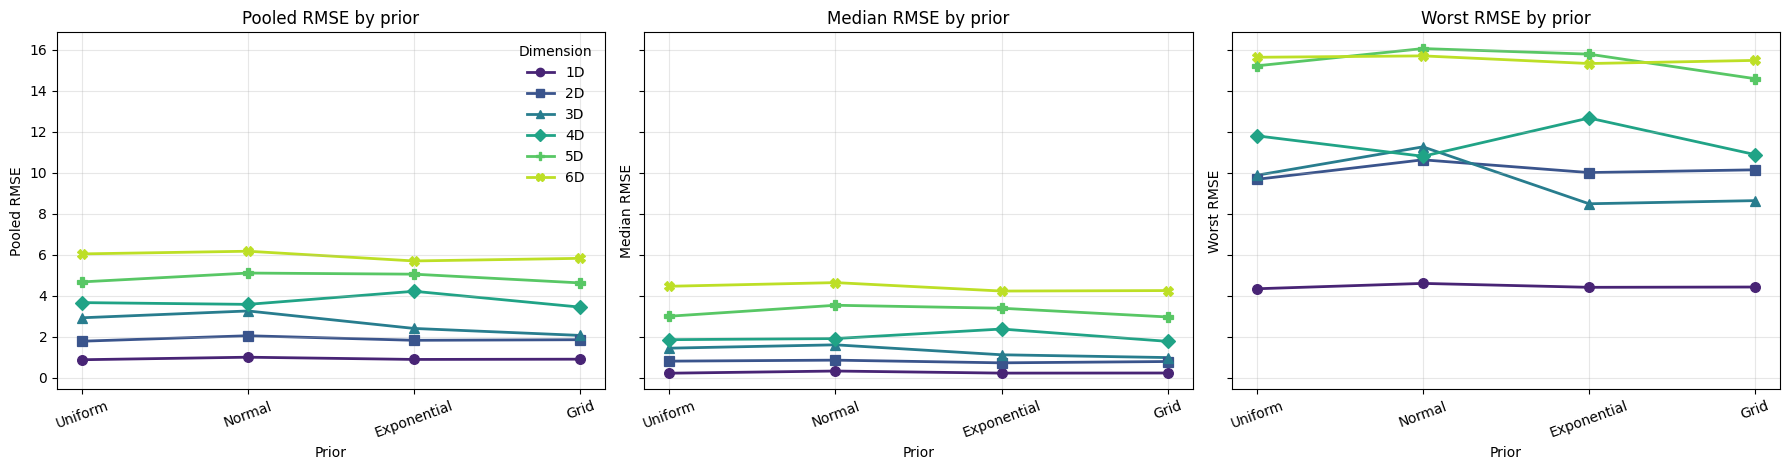

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True, sharey=True)
plot_metric_vs_prior(axes[0], runs_df, "pooled_rmse_log_r10", "Pooled RMSE by prior", "Pooled RMSE")
plot_metric_vs_prior(axes[1], runs_df, "median_rmse_log_r10", "Median RMSE by prior", "Median RMSE")
plot_metric_vs_prior(axes[2], runs_df, "worst_rmse_log_r10", "Worst RMSE by prior", "Worst RMSE")
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "accuracy_rmse_vs_prior")
plt.show()

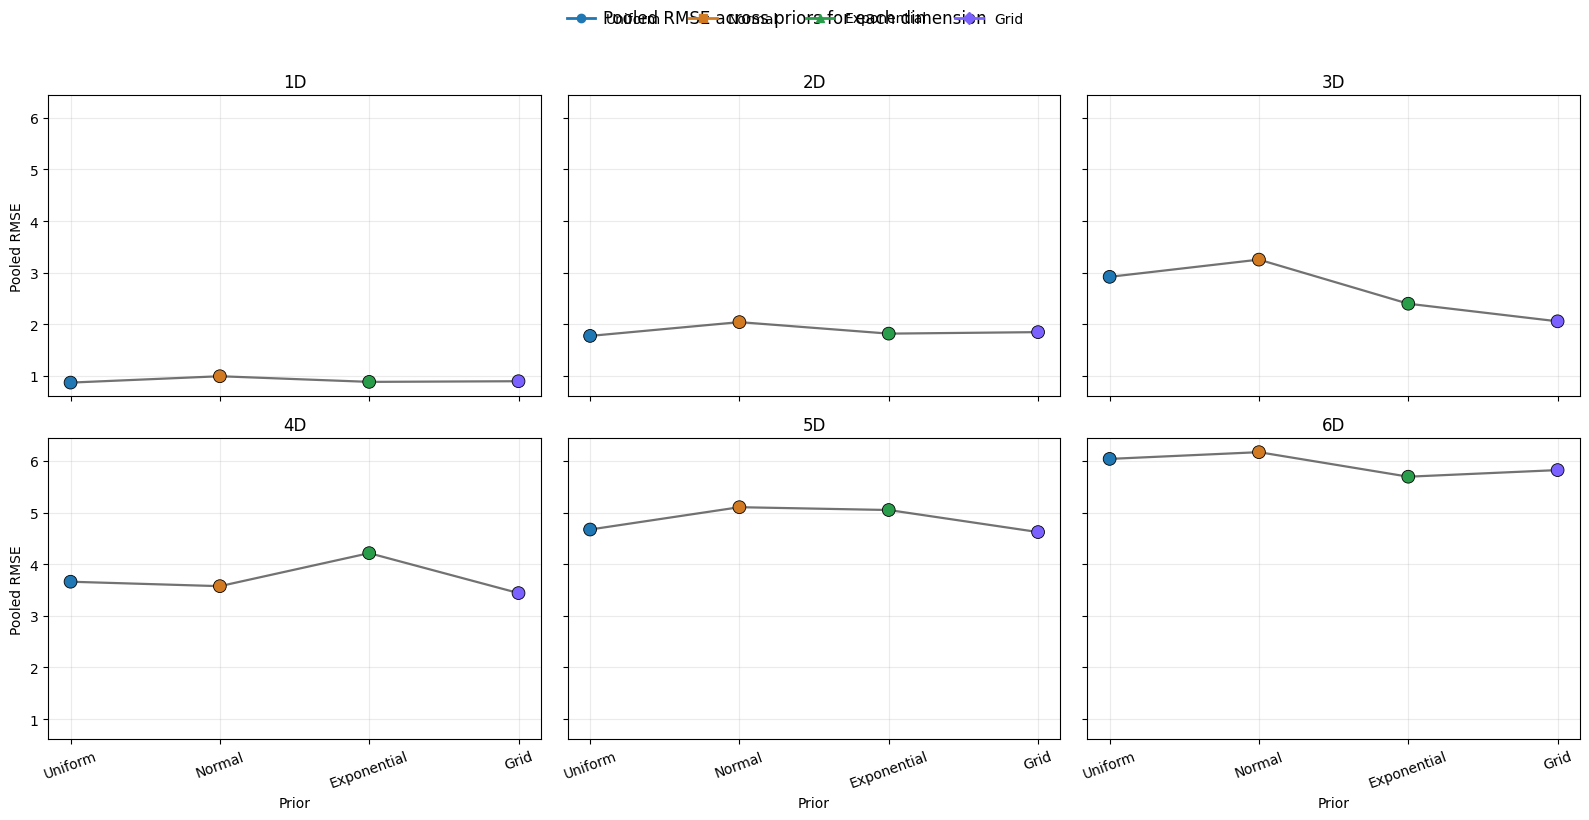

### Prior-focused interpretation
- **Grid** has the lowest mean pooled RMSE across the 1D-6D sweep (**3.115**).
- **Normal** has the largest average median ESS fraction (**0.047**), so it tends to preserve the strongest reweighting support.
- **Normal** is closest to nominal 68% coverage on average, with a mean absolute coverage gap of **0.191**.
- In the dimension-by-dimension win table, **Exponential** collects the most metric wins (**10** total).
- Relative to the uniform baseline, **Grid** yields the strongest mean pooled-RMSE improvement (**-0.208**).

In [7]:
fig = plot_metric_by_dimension_panels(
    runs_df,
    "pooled_rmse_log_r10",
    "Pooled RMSE across priors for each dimension",
    "Pooled RMSE",
    sharey=True,
)
save_figure(fig, "accuracy_pooled_rmse_by_dimension")
plt.show()

display(build_prior_observation_markdown(prior_summary_df, prior_win_count_df, delta_vs_uniform_df))

## Reweighting Quality

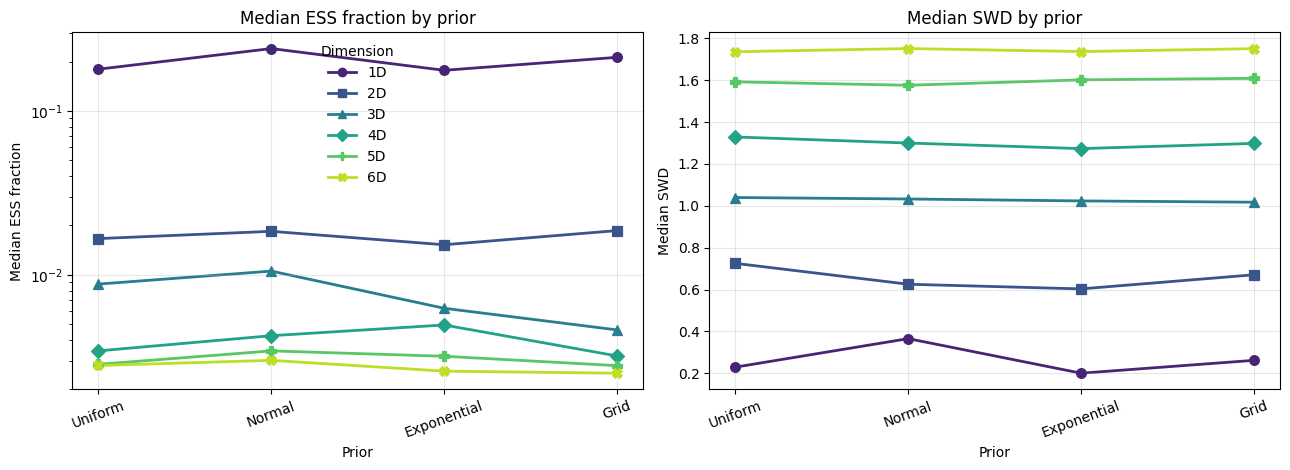

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "median_ess_fraction", "Median ESS fraction by prior", "Median ESS fraction", logy=True)
plot_metric_vs_prior(axes[1], runs_df, "median_swd", "Median SWD by prior", "Median SWD")
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "reweighting_metrics_vs_prior")
plt.show()

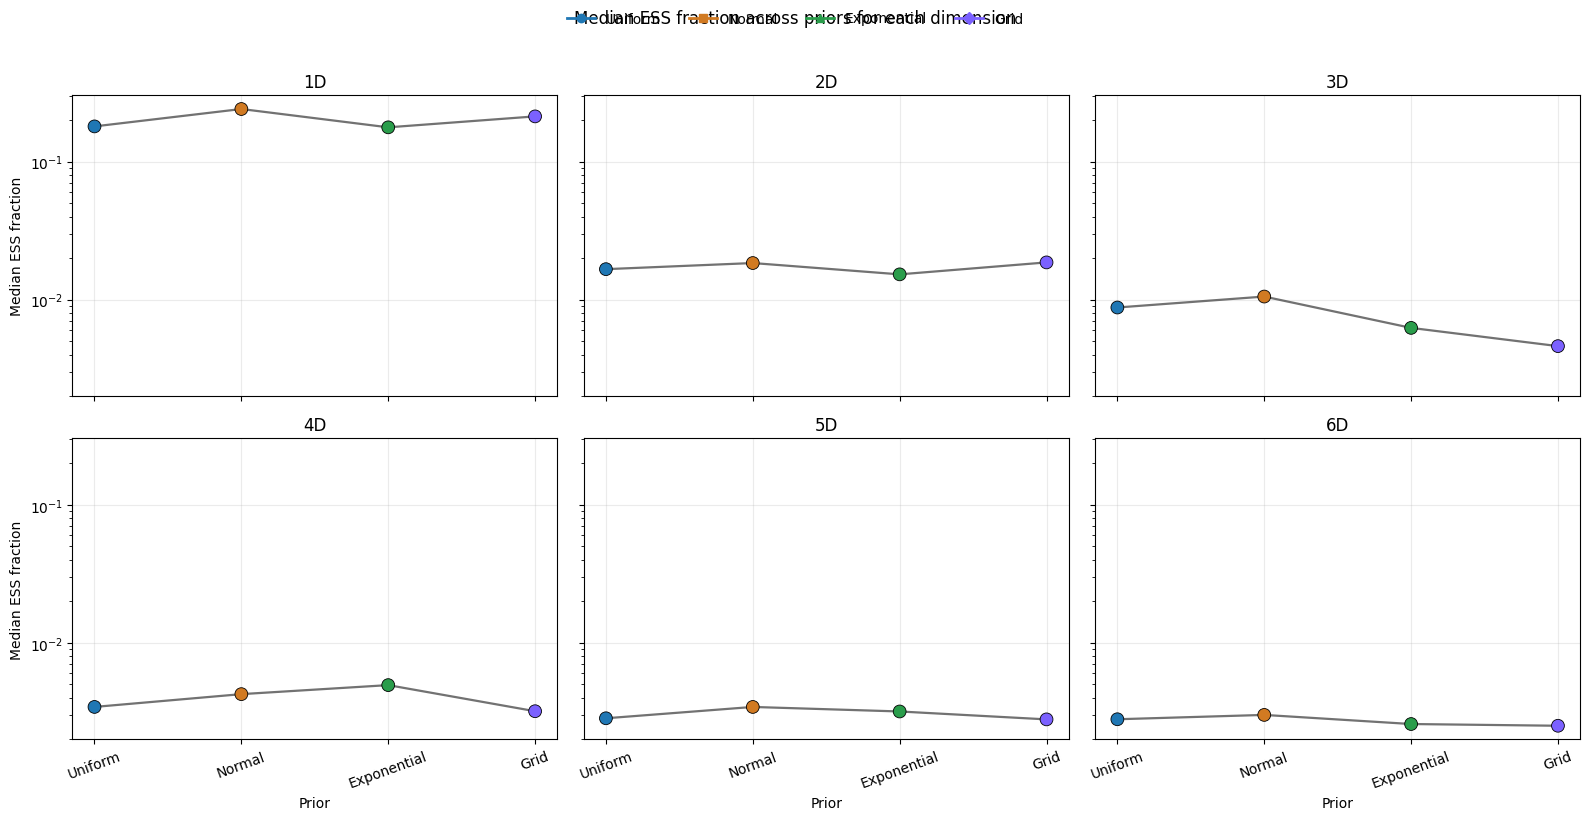

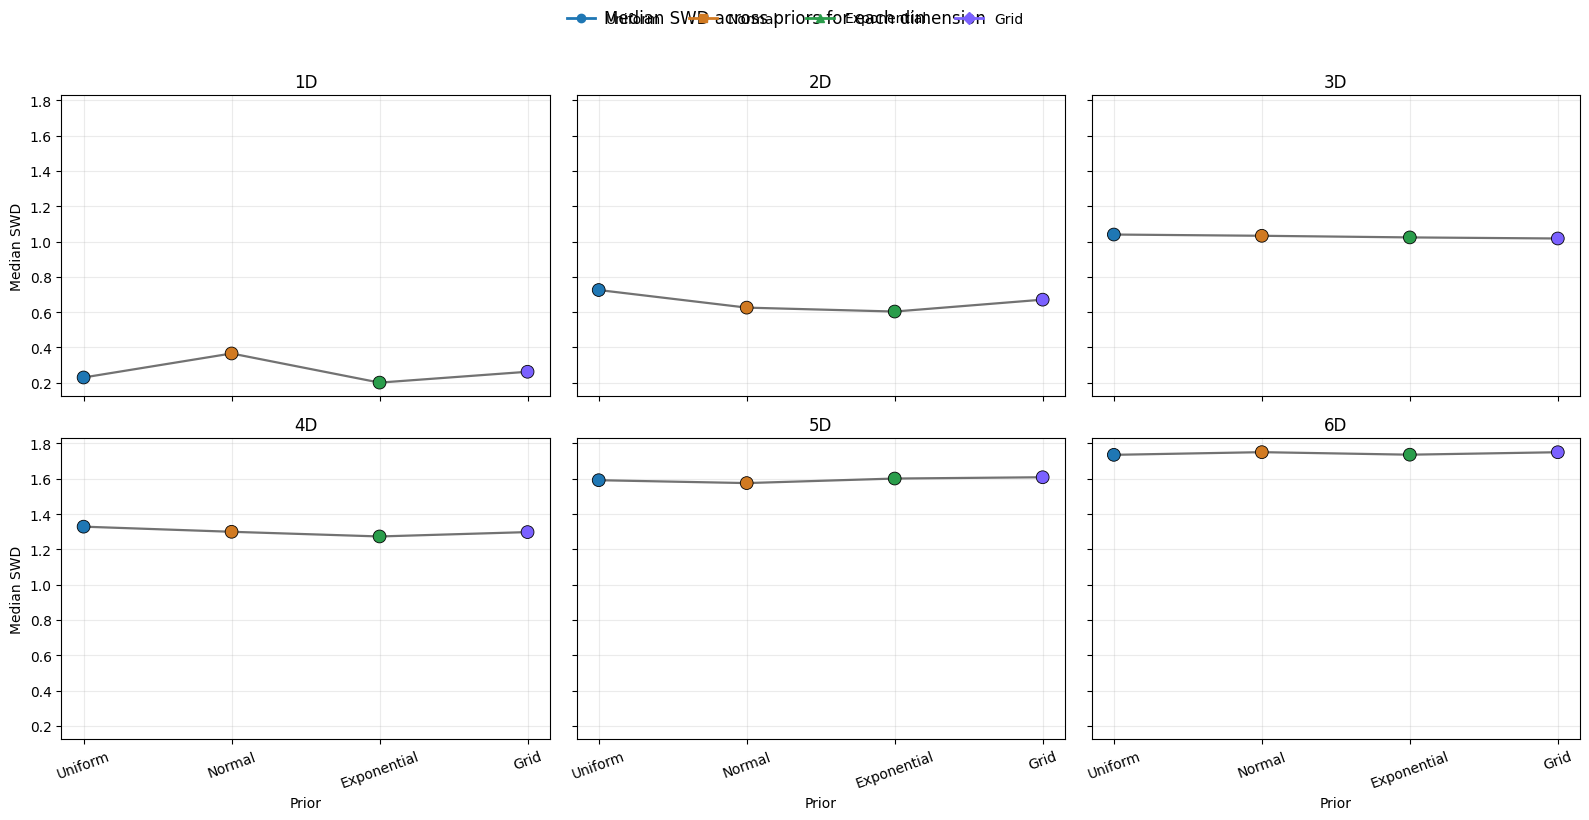

In [9]:
fig = plot_metric_by_dimension_panels(
    runs_df,
    "median_ess_fraction",
    "Median ESS fraction across priors for each dimension",
    "Median ESS fraction",
    logy=True,
    sharey=True,
)
save_figure(fig, "reweighting_ess_fraction_by_dimension")
plt.show()

fig = plot_metric_by_dimension_panels(
    runs_df,
    "median_swd",
    "Median SWD across priors for each dimension",
    "Median SWD",
    sharey=True,
)
save_figure(fig, "reweighting_swd_by_dimension")
plt.show()

## Calibration And Uncertainty

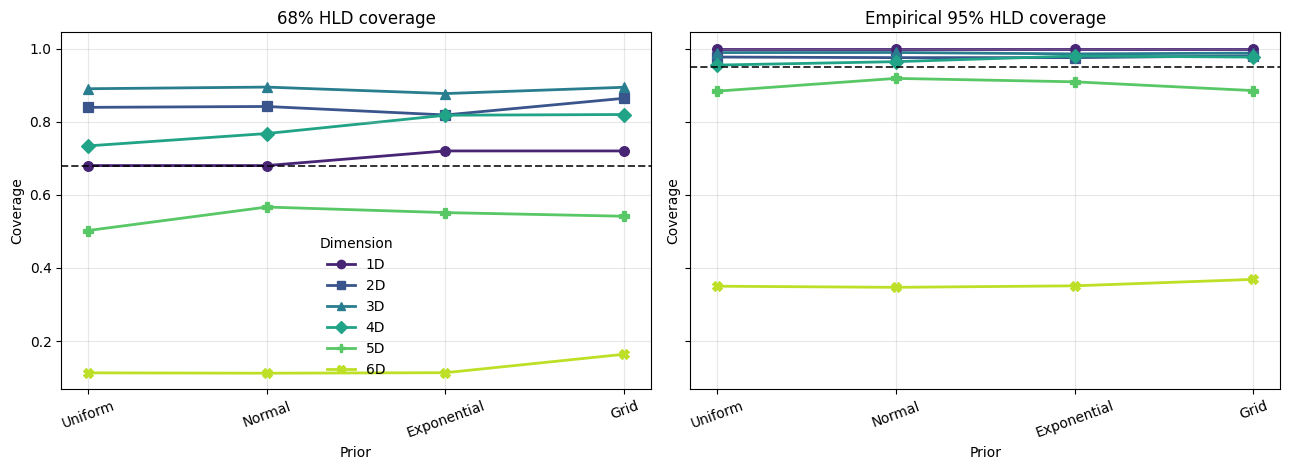

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
plot_metric_vs_prior(axes[0], runs_df, "coverage_68", "68% HLD coverage", "Coverage", nominal=0.68)
plot_metric_vs_prior(axes[1], runs_df, "coverage_95", "Empirical 95% HLD coverage", "Coverage", nominal=0.95)
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "calibration_coverage_vs_prior")
plt.show()

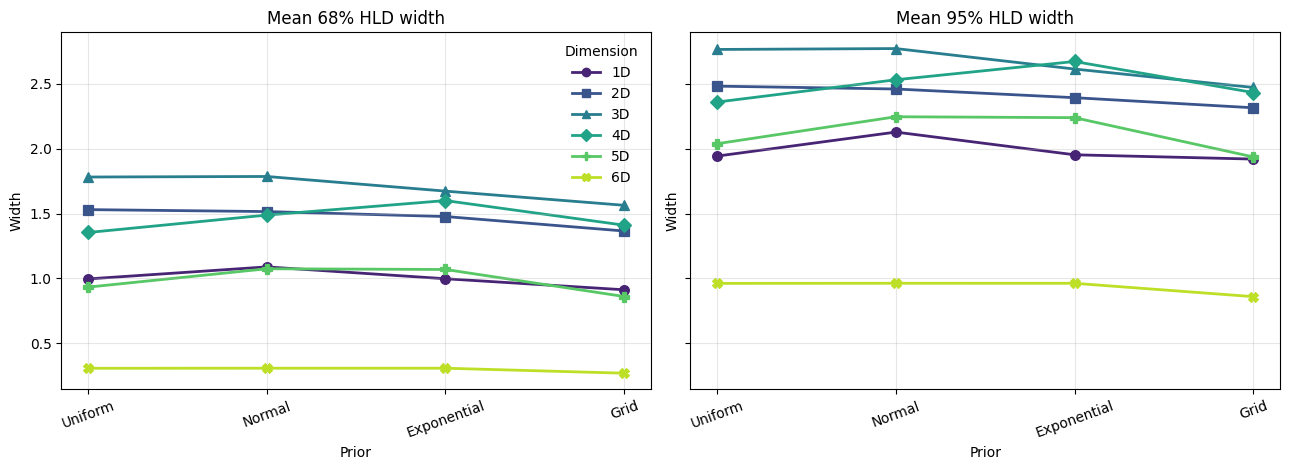

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True, sharey=True)
plot_metric_vs_prior(axes[0], runs_df, "mean_interval_width_68", "Mean 68% HLD width", "Width")
plot_metric_vs_prior(axes[1], runs_df, "mean_interval_width_95", "Mean 95% HLD width", "Width")
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
fig.tight_layout()
save_figure(fig, "calibration_interval_width_vs_prior")
plt.show()

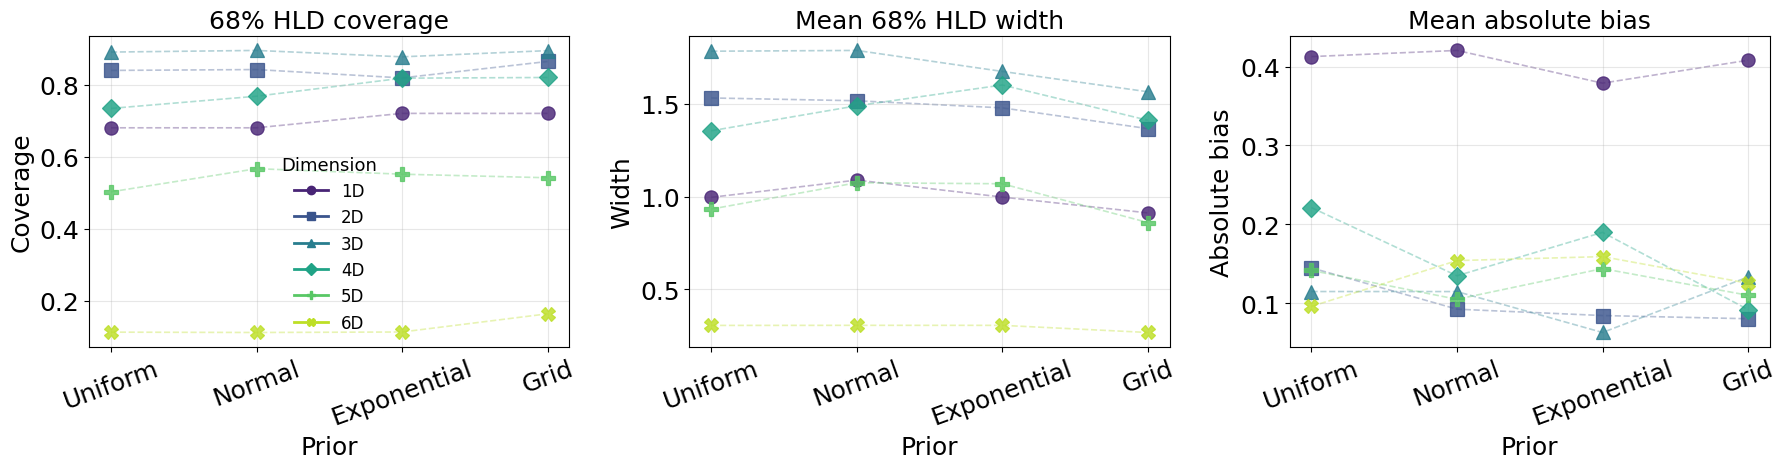

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "coverage_68", "68% HLD coverage", "Coverage", connect_points=True, marker_size=9.5, marker_alpha=0.82, line_alpha=0.35, line_style="--", line_width=1.2)
plot_metric_vs_prior(axes[1], runs_df, "mean_interval_width_68", "Mean 68% HLD width", "Width", connect_points=True, marker_size=9.5, marker_alpha=0.82, line_alpha=0.35, line_style="--", line_width=1.2)
plot_metric_vs_prior(axes[2], bias_summary_df, "mean_abs_bias", "Mean absolute bias", "Absolute bias", connect_points=True, marker_size=9.5, marker_alpha=0.82, line_alpha=0.35, line_style="--", line_width=1.2)
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension", fontsize=12, title_fontsize=13)
for ax in axes:
    ax.title.set_fontsize(18)
    ax.xaxis.label.set_fontsize(18)
    ax.yaxis.label.set_fontsize(18)
    ax.tick_params(axis="both", labelsize=18)
fig.tight_layout()
save_figure(fig, "calibration_68_coverage_width_bias_vs_prior")
plt.show()

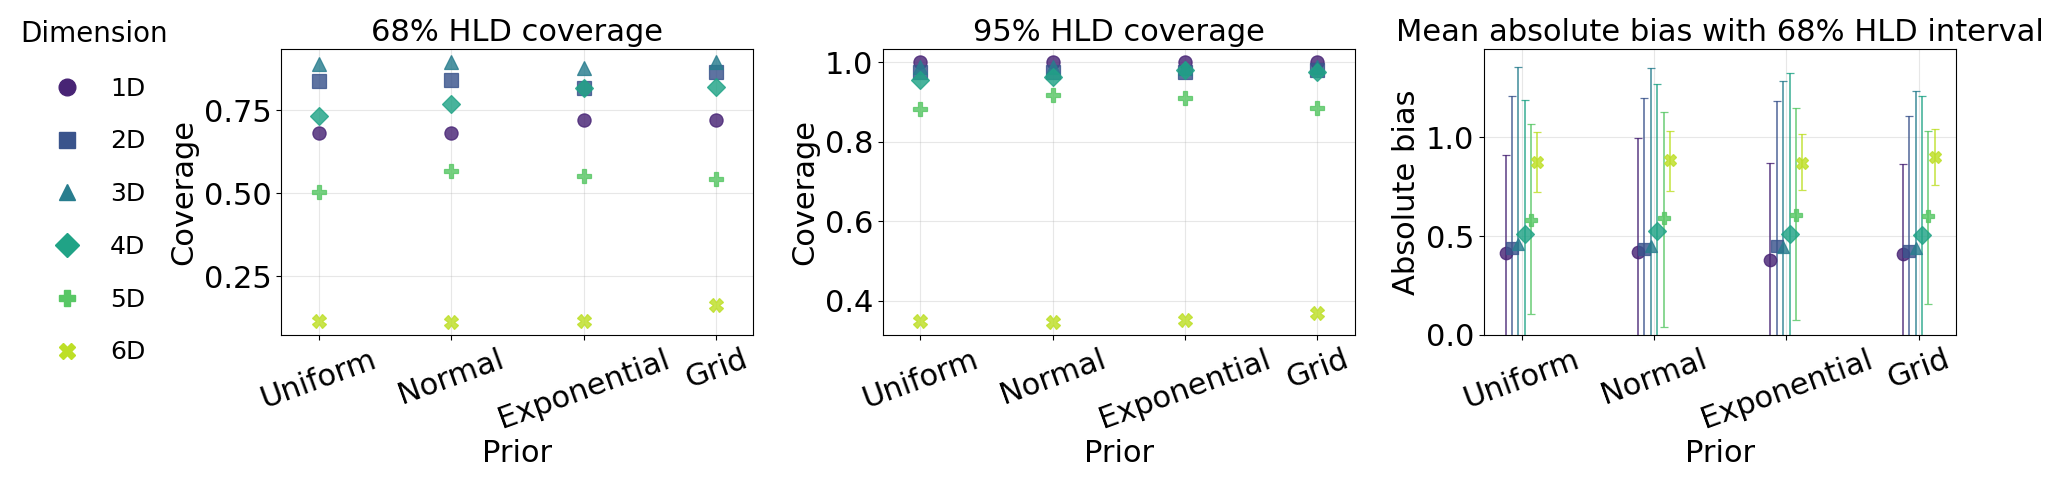

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
plot_metric_vs_prior(axes[0], runs_df, "coverage_68", "68% HLD coverage", "Coverage", connect_points=False, marker_size=9.5, marker_alpha=0.82)
plot_metric_vs_prior(axes[1], runs_df, "coverage_95", "95% HLD coverage", "Coverage", connect_points=False, marker_size=9.5, marker_alpha=0.82)

bias_interval_df = build_map_hld_interval_summary(raw_map_df, raw_intervals_df, interval_level="68")
if bias_interval_df.empty:
    raise ValueError(
        "Raw MAP/HLD interval data are required for the asymmetric bias interval panel. "
        "Set LOAD_RAW = True and rerun the loading cell."
    )
priors = active_priors(bias_interval_df)
dimensions = ordered_dimensions(bias_interval_df)
x_positions = np.arange(len(priors))
x_offsets = np.linspace(-0.12, 0.12, num=max(len(dimensions), 1))
colors, markers = build_dimension_style_maps(dimensions)
for index, dimension in enumerate(dimensions):
    subset = bias_interval_df.loc[bias_interval_df["dimension"] == dimension].copy()
    subset["prior"] = subset["prior"].astype(str)
    subset = subset.set_index("prior").reindex(priors).reset_index()
    lower_errors = subset["mean_lower_map_distance"].to_numpy(dtype=float)
    upper_errors = subset["mean_upper_map_distance"].to_numpy(dtype=float)
    axes[2].errorbar(
        x_positions + x_offsets[index],
        subset["mean_abs_bias"],
        yerr=np.vstack([lower_errors, upper_errors]),
        fmt=markers[dimension],
        linestyle="none",
        color=colors[dimension],
        ecolor=colors[dimension],
        markersize=9.0,
        alpha=0.82,
        elinewidth=1.2,
        capsize=3.0,
        capthick=1.2,
        markeredgewidth=0.9,
        zorder=2,
    )
interval_low = bias_interval_df["mean_abs_bias"] - bias_interval_df["mean_lower_map_distance"]
interval_high = bias_interval_df["mean_abs_bias"] + bias_interval_df["mean_upper_map_distance"]
padding = 0.05 * float(interval_high.max() - interval_low.min())
if not np.isfinite(padding) or padding == 0.0:
    padding = 0.05
axes[2].set_ylim(0.0, float(interval_high.max() + padding))
axes[2].set_title("Mean absolute bias with 68% HLD interval")
axes[2].set_xlabel("Prior")
axes[2].set_ylabel("Absolute bias")
axes[2].set_xticks(x_positions)
axes[2].set_xticklabels([PRIOR_LABELS.get(prior, prior) for prior in priors], rotation=20)
axes[2].grid(alpha=0.3)

legend_dimensions = ordered_dimensions(runs_df)
legend_colors, legend_markers = build_dimension_style_maps(legend_dimensions)
legend_handles = [
    Line2D(
        [0],
        [0],
        color=legend_colors[dimension],
        marker=legend_markers[dimension],
        markersize=12,
        markeredgewidth=1.0,
        linestyle="none",
        linewidth=0,
        label=f"{dimension}D",
    )
    for dimension in legend_dimensions
]
for ax in axes:
    ax.title.set_fontsize(22)
    ax.xaxis.label.set_fontsize(22)
    ax.yaxis.label.set_fontsize(22)
    ax.tick_params(axis="both", labelsize=22)
fig.tight_layout()
if legend_handles:
    axes[0].legend(
        handles=legend_handles,
        frameon=False,
        title="Dimension",
        fontsize=18,
        title_fontsize=20,
        loc="center right",
        bbox_to_anchor=(-0.22, 0.5),
        borderaxespad=0.0,
        handletextpad=0.7,
        labelspacing=1.15,
    )
save_figure(fig, "calibration_68_coverage_width_bias_interval_vs_prior")
plt.show()


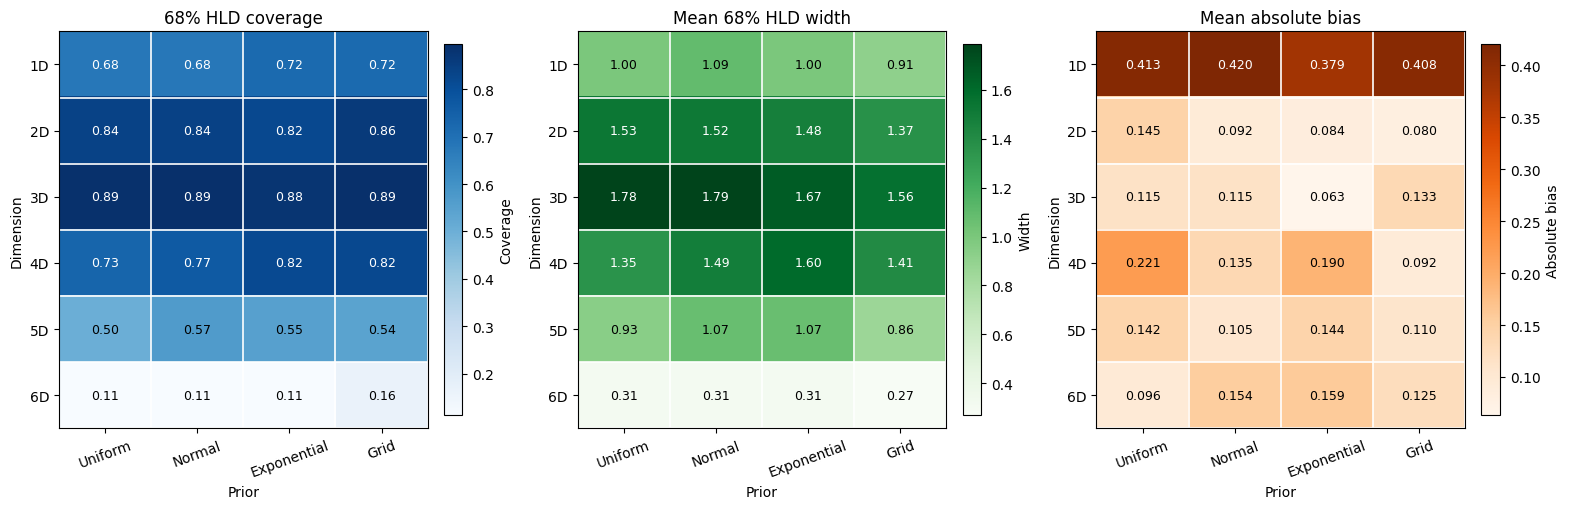

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15.8, 5.2))
coverage_image = plot_metric_heatmap(
    axes[0],
    runs_df,
    "coverage_68",
    "68% HLD coverage",
    "Coverage",
    cmap="Blues",
    annotate=True,
    fmt=".2f",
)
width_image = plot_metric_heatmap(
    axes[1],
    runs_df,
    "mean_interval_width_68",
    "Mean 68% HLD width",
    "Width",
    cmap="Greens",
    annotate=True,
    fmt=".2f",
)
bias_image = plot_metric_heatmap(
    axes[2],
    bias_summary_df,
    "mean_abs_bias",
    "Mean absolute bias",
    "Absolute bias",
    cmap="Oranges",
    annotate=True,
    fmt=".3f",
)
for ax, image in zip(axes, [coverage_image, width_image, bias_image]):
    colorbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label(image.colorbar_label)
fig.tight_layout()
save_figure(fig, "calibration_68_coverage_width_bias_heatmaps")
plt.show()


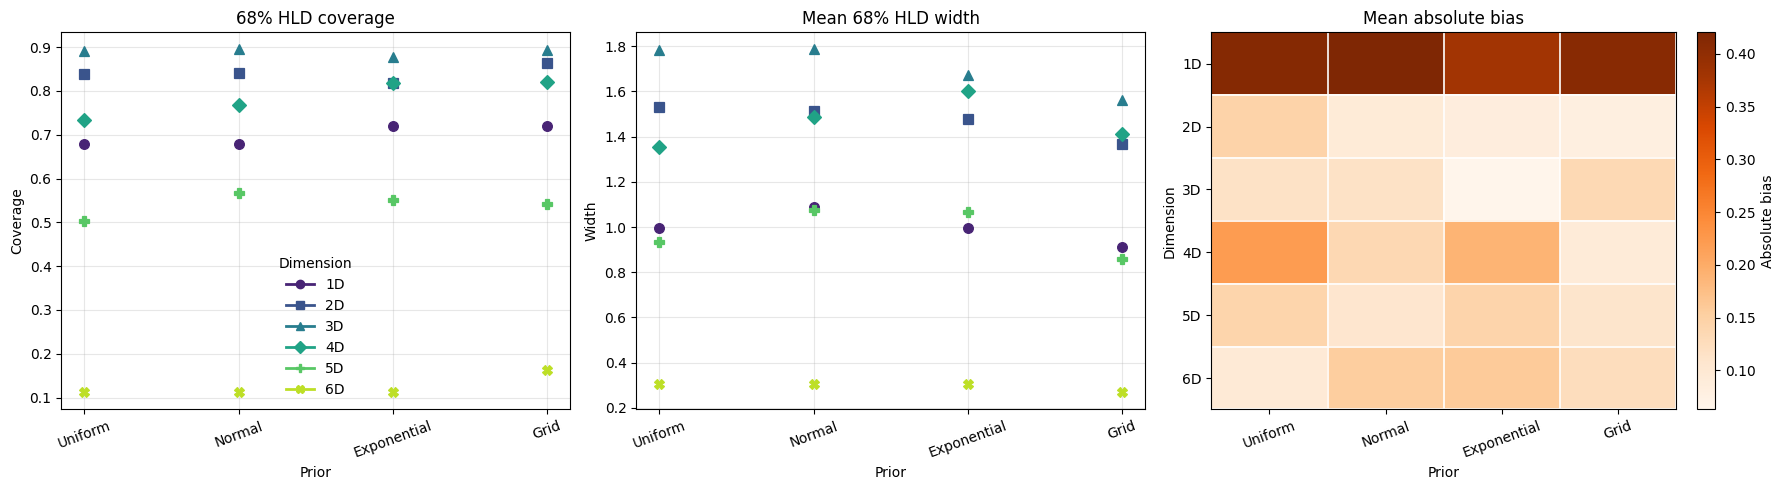

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.0))
plot_metric_vs_prior(axes[0], runs_df, "coverage_68", "68% HLD coverage", "Coverage", connect_points=False)
plot_metric_vs_prior(axes[1], runs_df, "mean_interval_width_68", "Mean 68% HLD width", "Width", connect_points=False)
bias_image = plot_metric_heatmap(
    axes[2],
    bias_summary_df,
    "mean_abs_bias",
    "Mean absolute bias",
    "Absolute bias",
    cmap="Oranges",
    annotate=False,
    fmt=".3f",
)
legend_handles = build_dimension_legend_handles(ordered_dimensions(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Dimension")
colorbar = fig.colorbar(bias_image, ax=axes[2], fraction=0.046, pad=0.04)
colorbar.set_label(bias_image.colorbar_label)
fig.tight_layout()
save_figure(fig, "calibration_68_coverage_width_bias_hybrid")
plt.show()


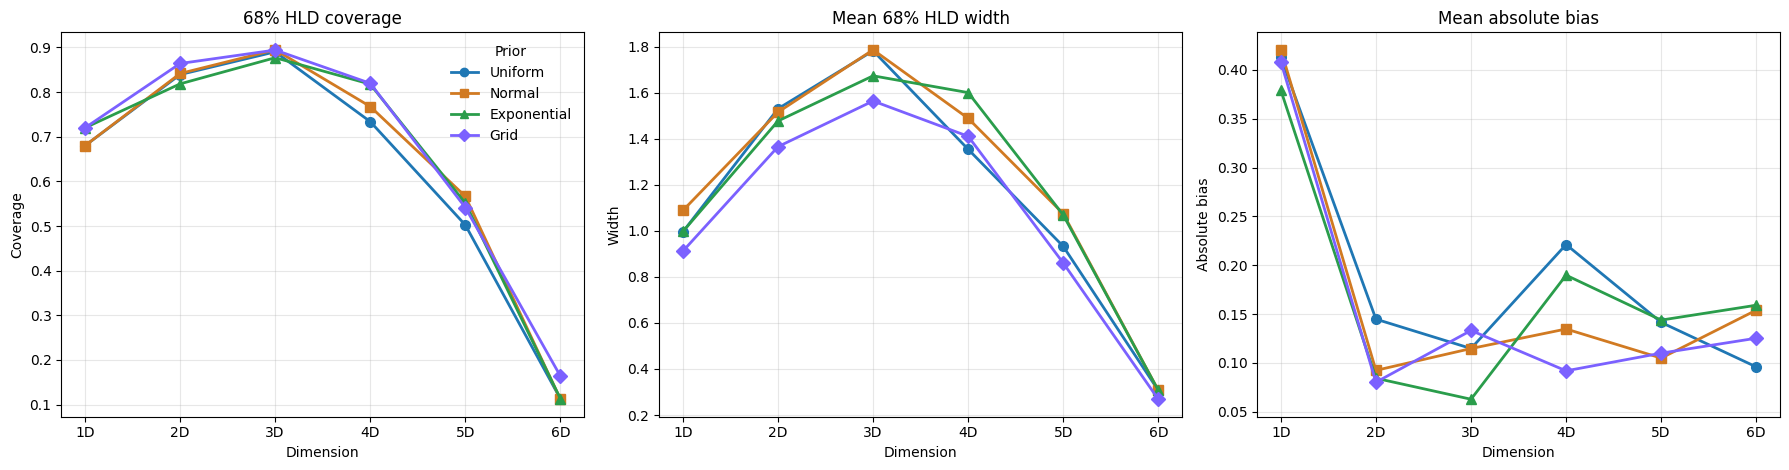

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharex=True)
plot_metric_vs_dimension(axes[0], runs_df, "coverage_68", "68% HLD coverage", "Coverage")
plot_metric_vs_dimension(axes[1], runs_df, "mean_interval_width_68", "Mean 68% HLD width", "Width")
plot_metric_vs_dimension(axes[2], bias_summary_df, "mean_abs_bias", "Mean absolute bias", "Absolute bias")
legend_handles = build_prior_legend_handles(active_priors(runs_df))
if legend_handles:
    axes[0].legend(handles=legend_handles, frameon=False, title="Prior")
fig.tight_layout()
save_figure(fig, "calibration_68_coverage_width_bias_vs_dimension")
plt.show()


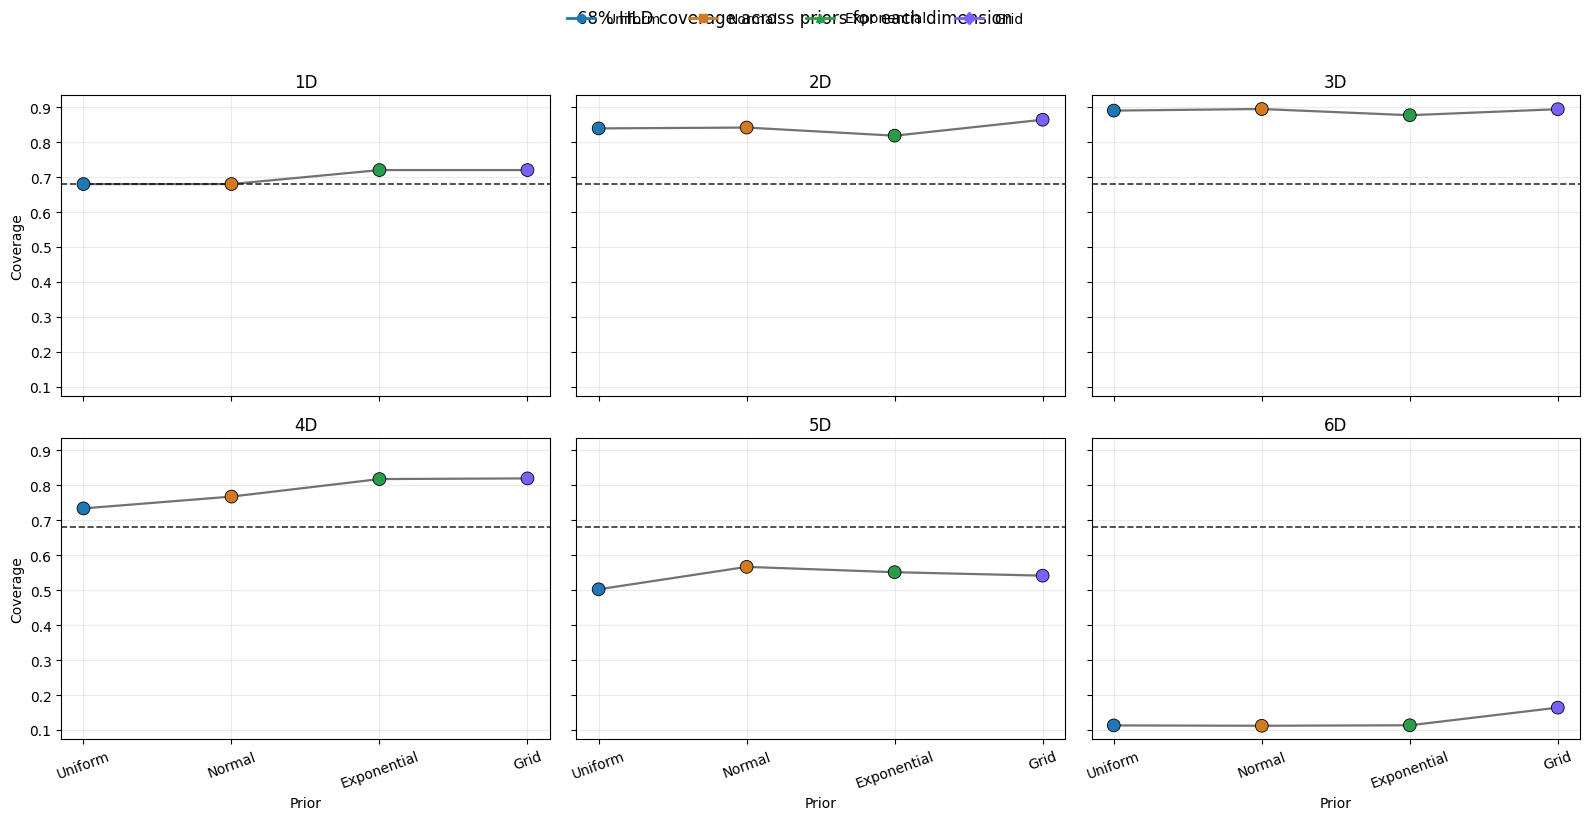

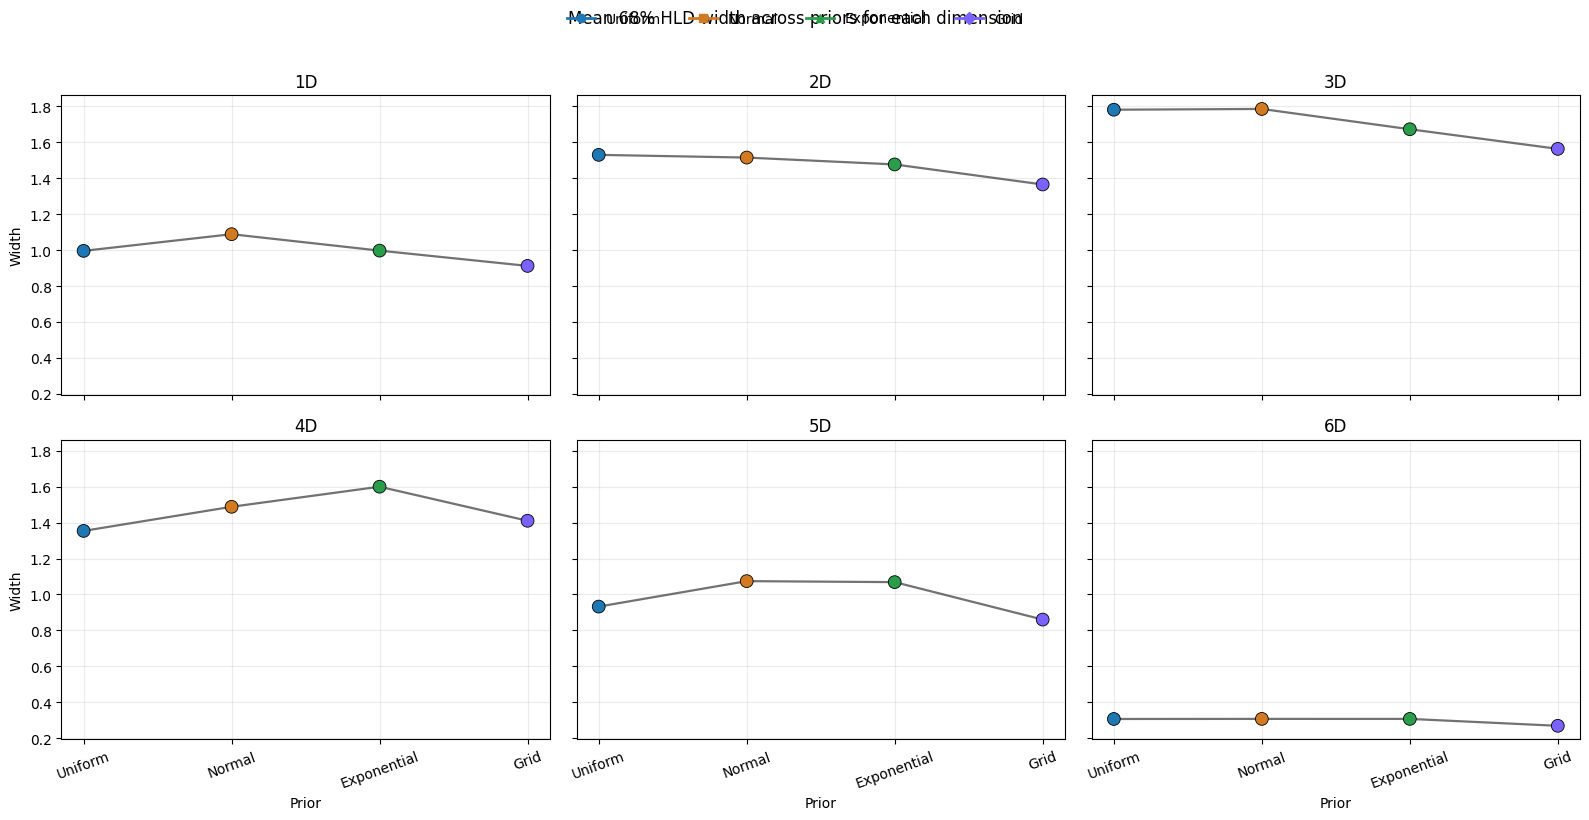

In [17]:
fig = plot_metric_by_dimension_panels(
    runs_df,
    "coverage_68",
    "68% HLD coverage across priors for each dimension",
    "Coverage",
    nominal=0.68,
    sharey=True,
)
save_figure(fig, "calibration_coverage_68_by_dimension")
plt.show()

fig = plot_metric_by_dimension_panels(
    runs_df,
    "mean_interval_width_68",
    "Mean 68% HLD width across priors for each dimension",
    "Width",
    sharey=True,
)
save_figure(fig, "calibration_interval_width_68_by_dimension")
plt.show()

## Distance-Driven Difficulty

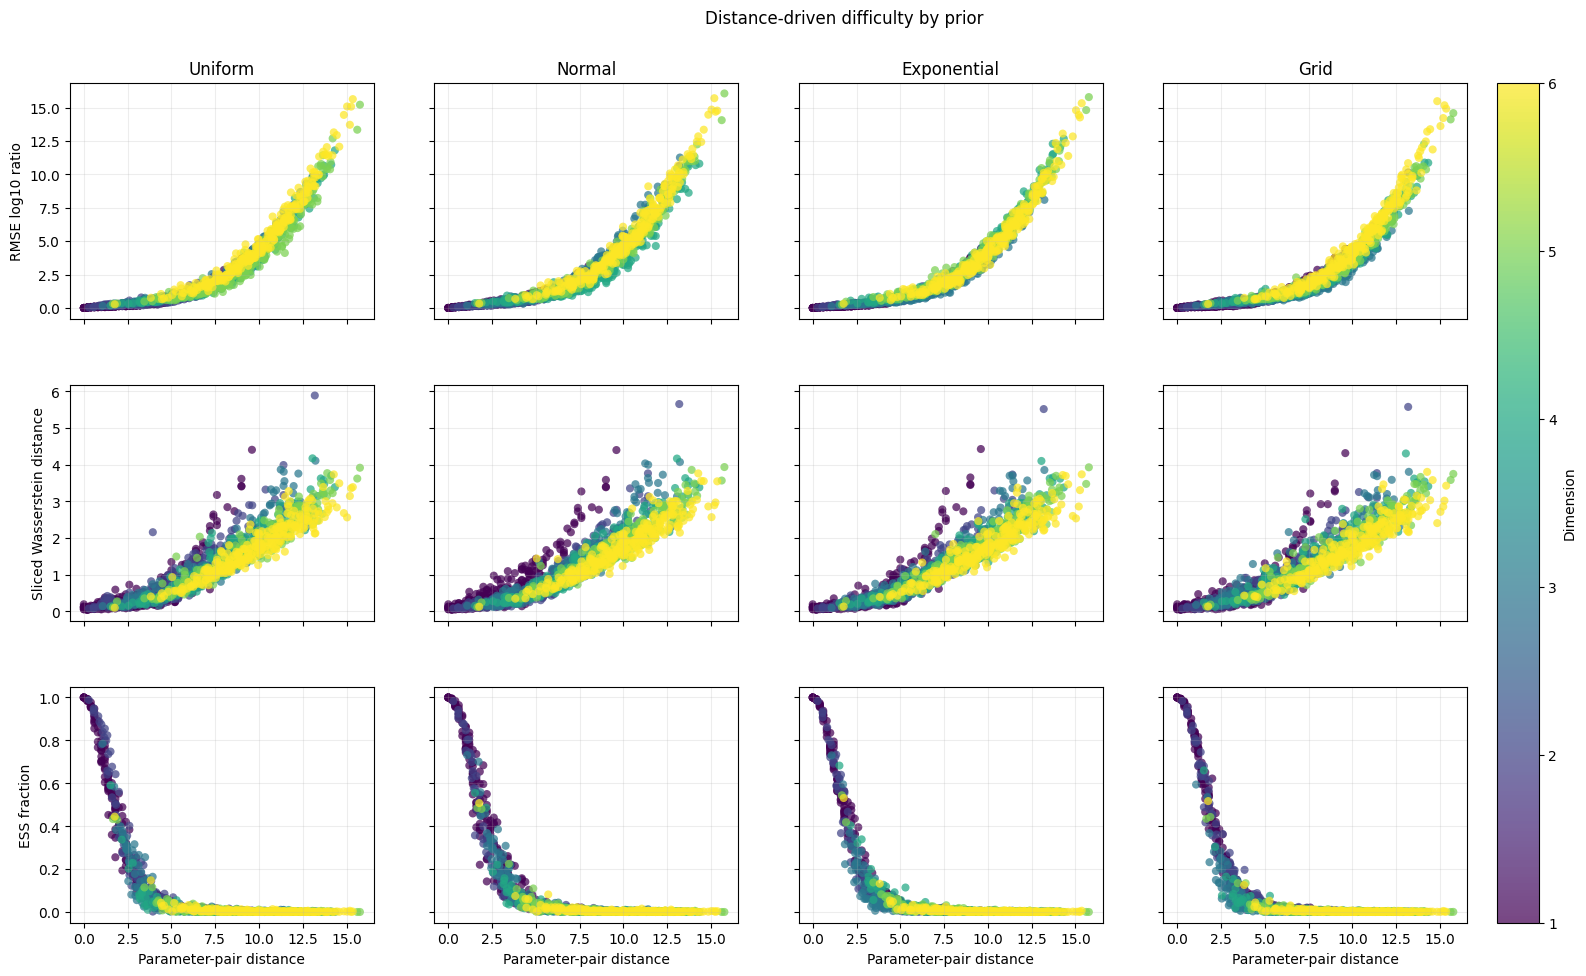

In [18]:
fig = plot_prior_facet_metric_grid(pairs_df)
fig.suptitle("Distance-driven difficulty by prior", y=0.99)
save_figure(fig, "difficulty_distance_vs_metrics_by_prior")
plt.show()

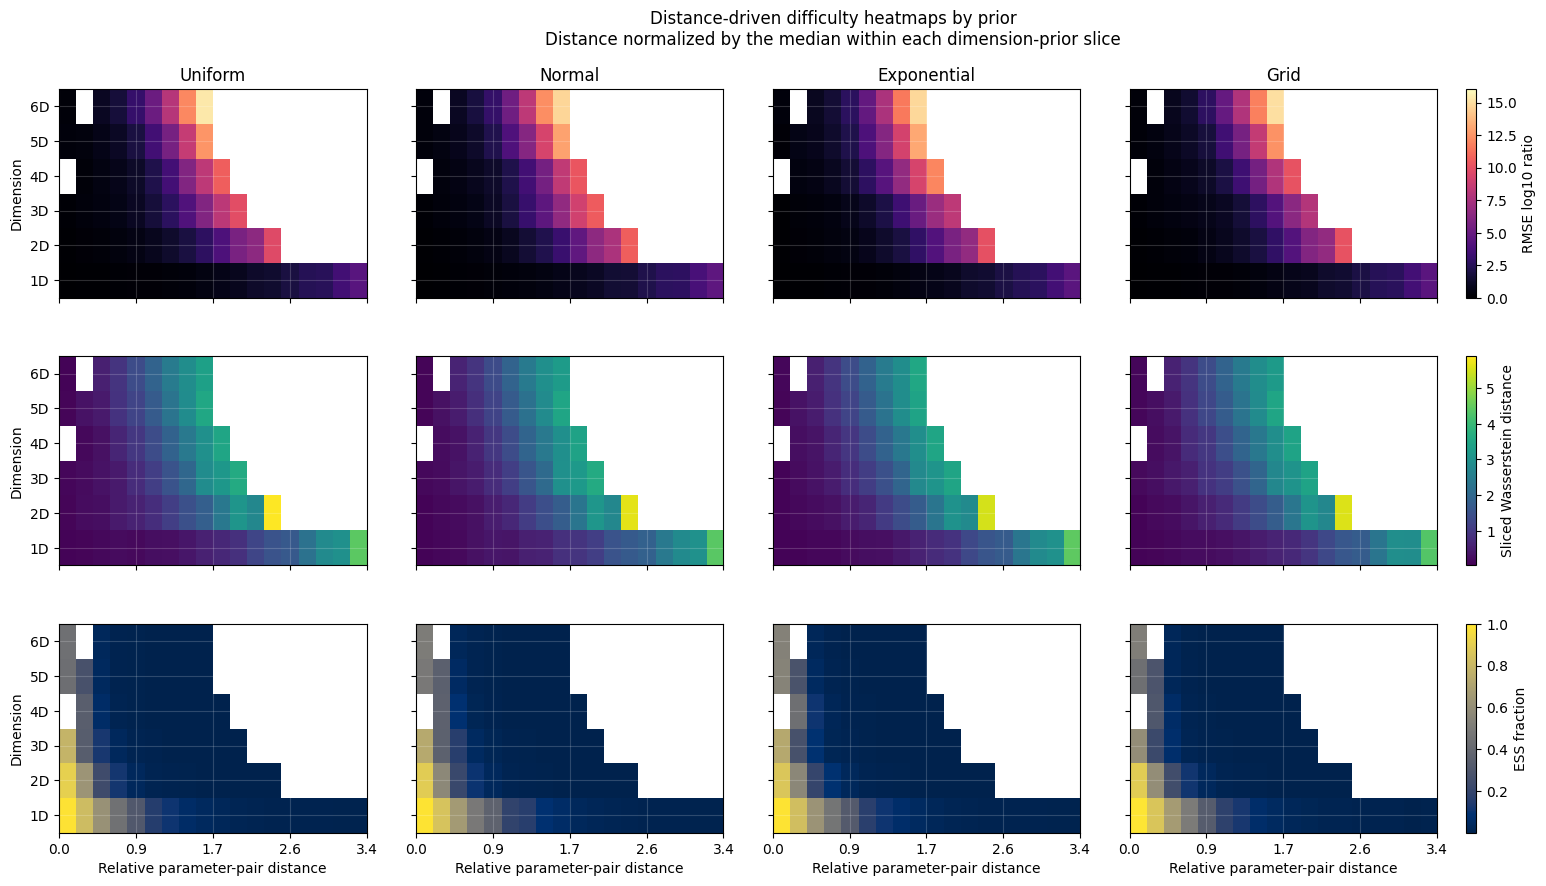

In [19]:
distance_heatmap_metrics = [
    ("rmse_log_r10", "RMSE log10 ratio", "magma"),
    ("swd", "Sliced Wasserstein distance", "viridis"),
    ("ess_fraction", "ESS fraction", "cividis"),
]
distance_bin_count = 18

if pairs_df.empty:
    display(Markdown("No pair-level metrics were loaded."))
else:
    heatmap_source = pairs_df.copy()
    heatmap_source["prior"] = heatmap_source["prior"].astype(str)
    heatmap_source["dimension"] = heatmap_source["dimension"].astype(int)
    heatmap_source["distance"] = pd.to_numeric(heatmap_source["distance"], errors="coerce")
    heatmap_source = heatmap_source.replace([np.inf, -np.inf], np.nan)
    median_distance = heatmap_source.groupby(["dimension", "prior"])["distance"].transform("median")
    heatmap_source["relative_distance"] = heatmap_source["distance"] / median_distance.where(median_distance > 0.0)
    finite_distances = heatmap_source["relative_distance"].dropna().to_numpy(dtype=float)

    if finite_distances.size == 0:
        display(Markdown("No finite parameter-pair distances were available for heatmap binning."))
    else:
        distance_min = float(finite_distances.min())
        distance_max = float(finite_distances.max())
        if np.isclose(distance_min, distance_max):
            distance_edges = np.array([distance_min - 0.5, distance_max + 0.5], dtype=float)
        else:
            distance_edges = np.linspace(distance_min, distance_max, distance_bin_count + 1)

        heatmap_source["distance_bin"] = pd.cut(
            heatmap_source["relative_distance"],
            bins=distance_edges,
            labels=False,
            include_lowest=True,
        )
        heatmap_source = heatmap_source.dropna(subset=["distance_bin"])
        heatmap_source["distance_bin"] = heatmap_source["distance_bin"].astype(int)

        priors = active_priors(heatmap_source)
        dimensions = ordered_dimensions(heatmap_source)
        distance_bins = np.arange(len(distance_edges) - 1)
        fig, axes = plt.subplots(
            len(distance_heatmap_metrics),
            len(priors),
            figsize=(4.4 * len(priors), 3.1 * len(distance_heatmap_metrics)),
            sharex=True,
            sharey=True,
            squeeze=False,
        )
        row_images = []

        for row, (metric, colorbar_label, cmap) in enumerate(distance_heatmap_metrics):
            metric_values = pd.to_numeric(heatmap_source[metric], errors="coerce").to_numpy(dtype=float)
            finite_metric_values = metric_values[np.isfinite(metric_values)]
            if finite_metric_values.size:
                vmin = float(finite_metric_values.min())
                vmax = float(finite_metric_values.max())
                if np.isclose(vmin, vmax):
                    span = max(abs(vmin) * 0.05, 1e-6)
                    vmin -= span
                    vmax += span
            else:
                vmin = None
                vmax = None

            row_image = None
            for column, prior in enumerate(priors):
                ax = axes[row, column]
                prior_subset = heatmap_source.loc[heatmap_source["prior"] == prior]
                heatmap = prior_subset.pivot_table(
                    index="dimension",
                    columns="distance_bin",
                    values=metric,
                    aggfunc="mean",
                ).reindex(index=dimensions, columns=distance_bins)
                image = ax.imshow(
                    np.ma.masked_invalid(heatmap.to_numpy(dtype=float)),
                    aspect="auto",
                    origin="lower",
                    cmap=cmap,
                    vmin=vmin,
                    vmax=vmax,
                    extent=[distance_edges[0], distance_edges[-1], -0.5, len(dimensions) - 0.5],
                )
                row_image = image
                if row == 0:
                    ax.set_title(PRIOR_LABELS.get(prior, prior))
                if column == 0:
                    ax.set_ylabel("Dimension")
                if row == len(distance_heatmap_metrics) - 1:
                    ax.set_xlabel("Relative parameter-pair distance")
                ax.set_yticks(np.arange(len(dimensions)))
                ax.set_yticklabels([f"{dimension}D" for dimension in dimensions])
                ax.grid(alpha=0.18, color="white", linewidth=0.8)
            row_images.append(row_image)

        x_ticks = np.linspace(distance_edges[0], distance_edges[-1], num=5)
        for ax in axes[-1, :]:
            ax.set_xticks(x_ticks)
            ax.set_xticklabels([f"{value:.1f}" for value in x_ticks])

        fig.subplots_adjust(left=0.06, right=0.88, bottom=0.11, top=0.91, wspace=0.16, hspace=0.28)
        for row, image in enumerate(row_images):
            colorbar = fig.colorbar(image, ax=axes[row, :].tolist(), fraction=0.025, pad=0.02)
            colorbar.set_label(distance_heatmap_metrics[row][1])
        fig.suptitle("Distance-driven difficulty heatmaps by prior\nDistance normalized by the median within each dimension-prior slice", y=0.995)
        save_figure(fig, "difficulty_distance_vs_metrics_heatmaps_by_prior")
        plt.show()

In [20]:
display(correlation_summary_df)

,dimension,prior,spearman_rmse_vs_distance,spearman_swd_vs_distance,spearman_ess_fraction_vs_distance
0,1,exponential,0.975,0.878,-0.990
1,1,grid,0.929,0.857,-0.990
2,1,normal,0.970,0.866,-0.979
3,1,uniform,0.963,0.839,-0.988
4,2,exponential,0.987,0.961,-0.936
5,2,grid,0.985,0.948,-0.928
6,2,normal,0.990,0.961,-0.936
7,2,uniform,0.970,0.922,-0.918
8,3,exponential,0.988,0.962,-0.848
9,3,grid,0.971,0.938,-0.805


## Position-Dependent Behavior

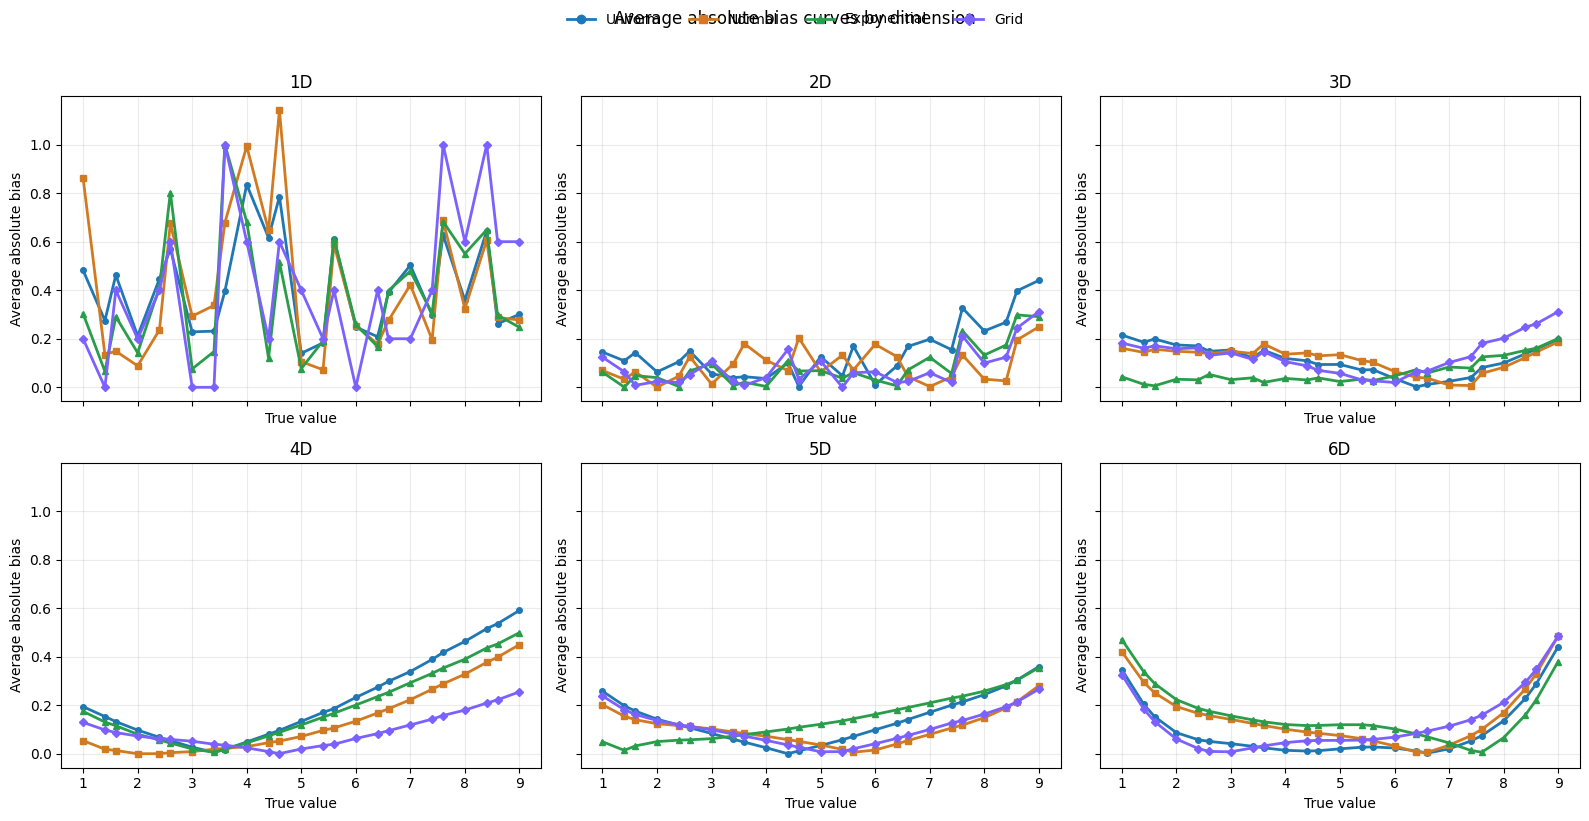

In [21]:
fig = plot_curve_by_dimension(curves_df, "abs_avg_bias", "Average absolute bias", "Average absolute bias curves by dimension")
save_figure(fig, "position_avg_bias_by_dimension")
plt.show()

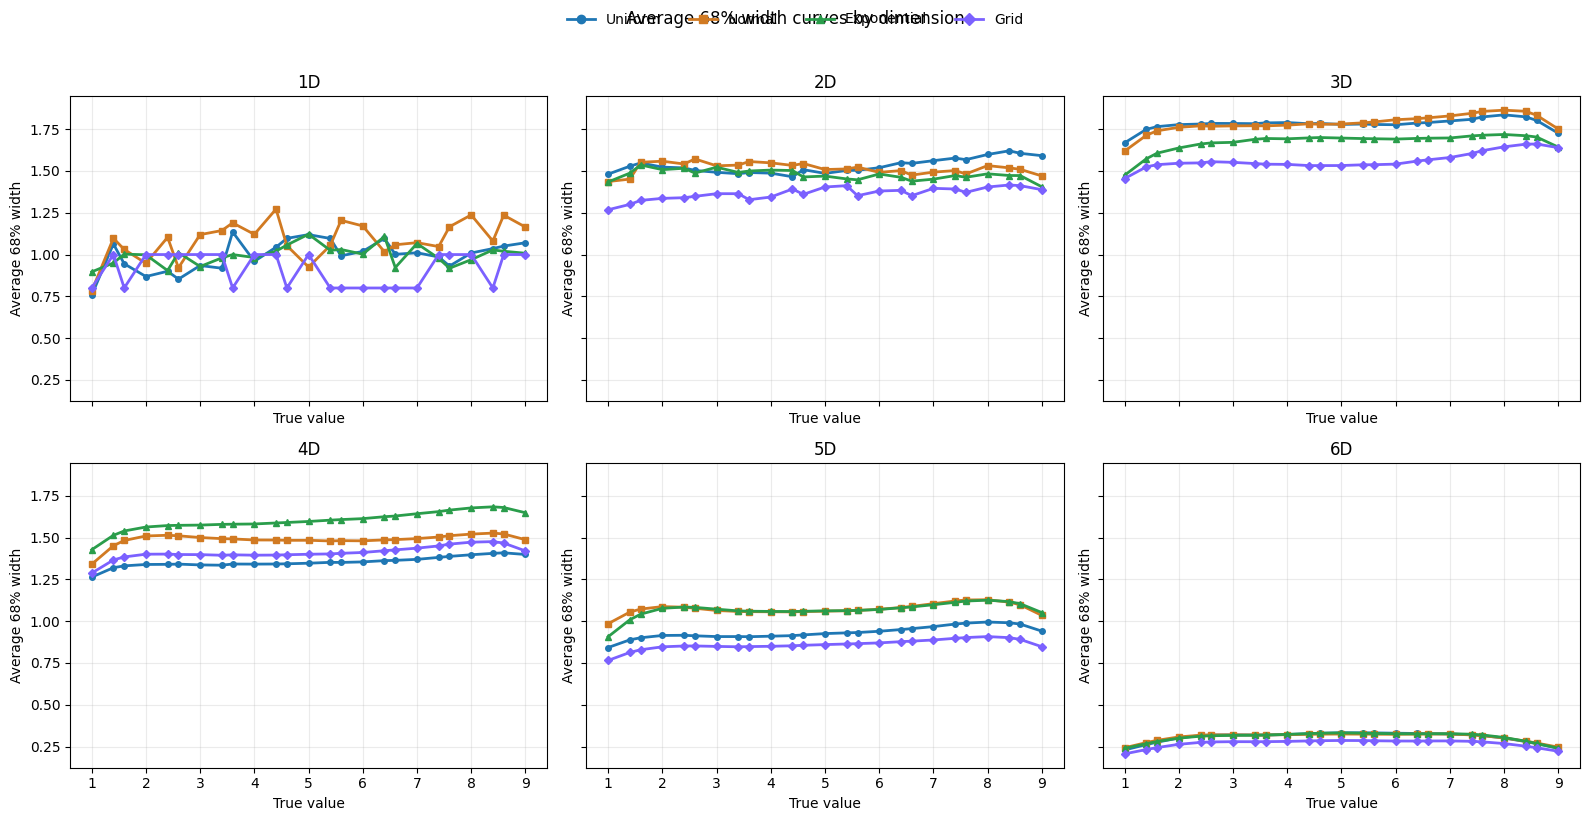

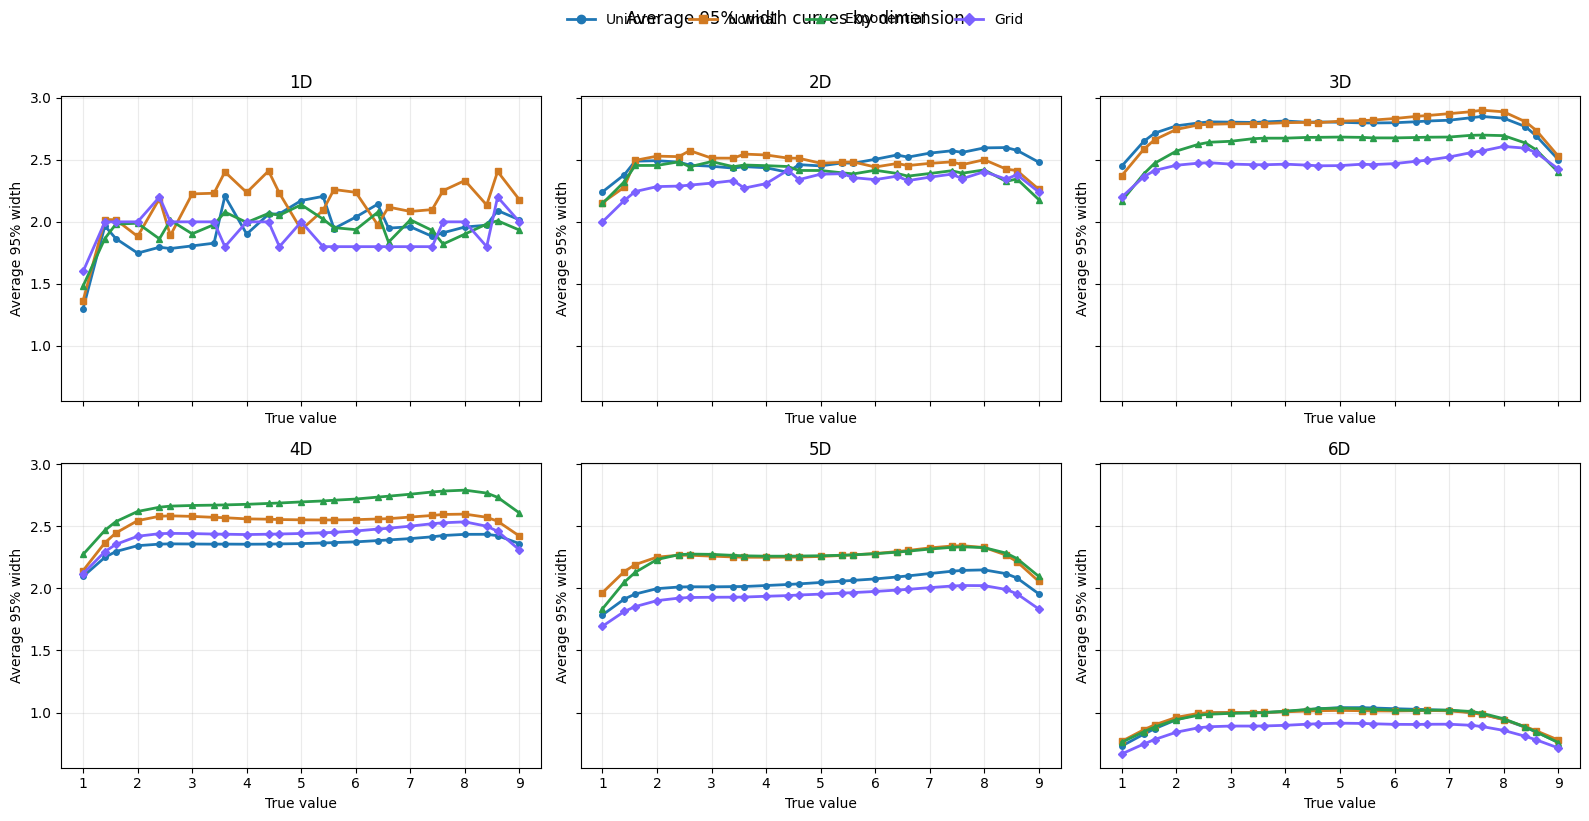

In [22]:
fig = plot_curve_by_dimension(curves_df, "avg_width_68", "Average 68% width", "Average 68% width curves by dimension")
save_figure(fig, "position_avg_width_68_by_dimension")
plt.show()

fig = plot_curve_by_dimension(curves_df, "avg_width_95", "Average 95% width", "Average 95% width curves by dimension")
save_figure(fig, "position_avg_width_95_by_dimension")
plt.show()

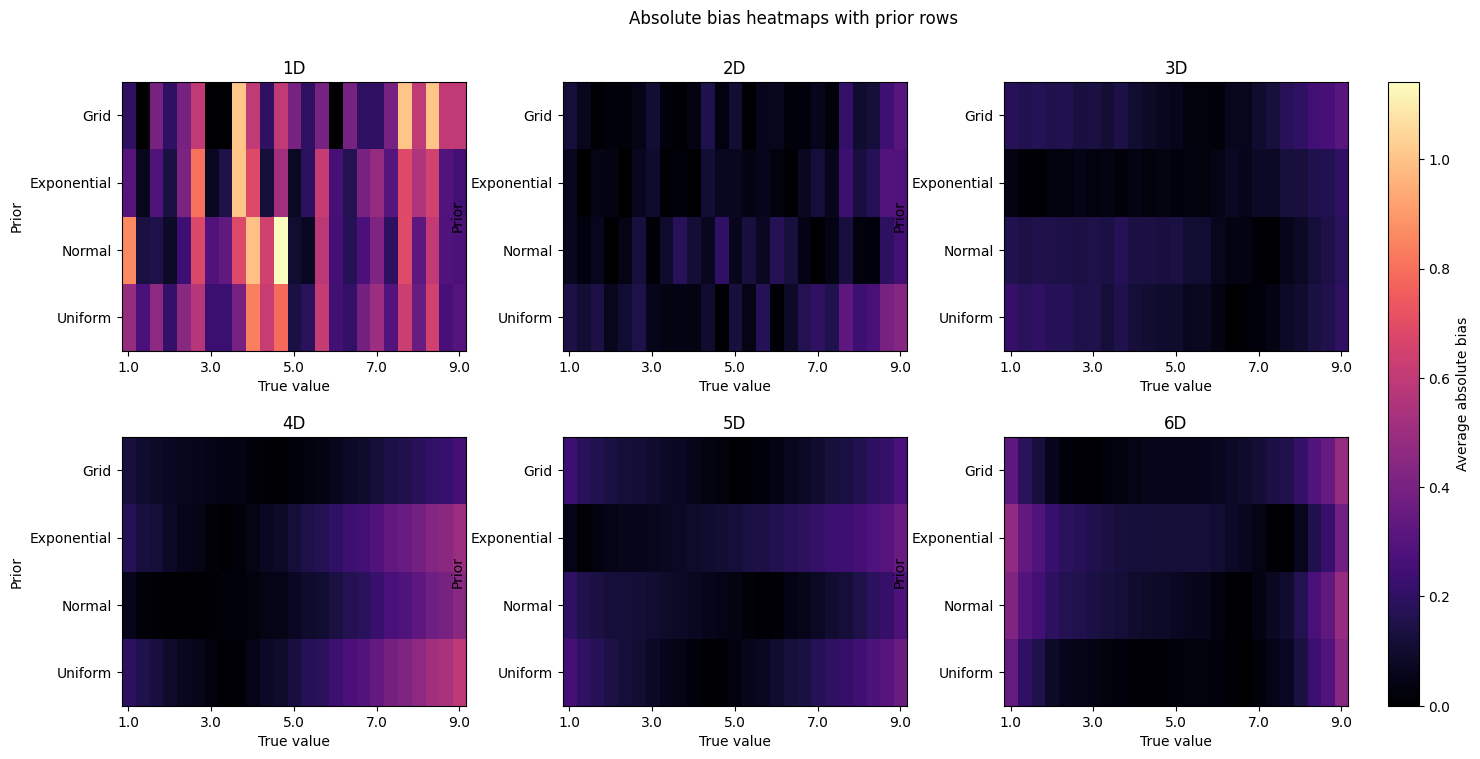

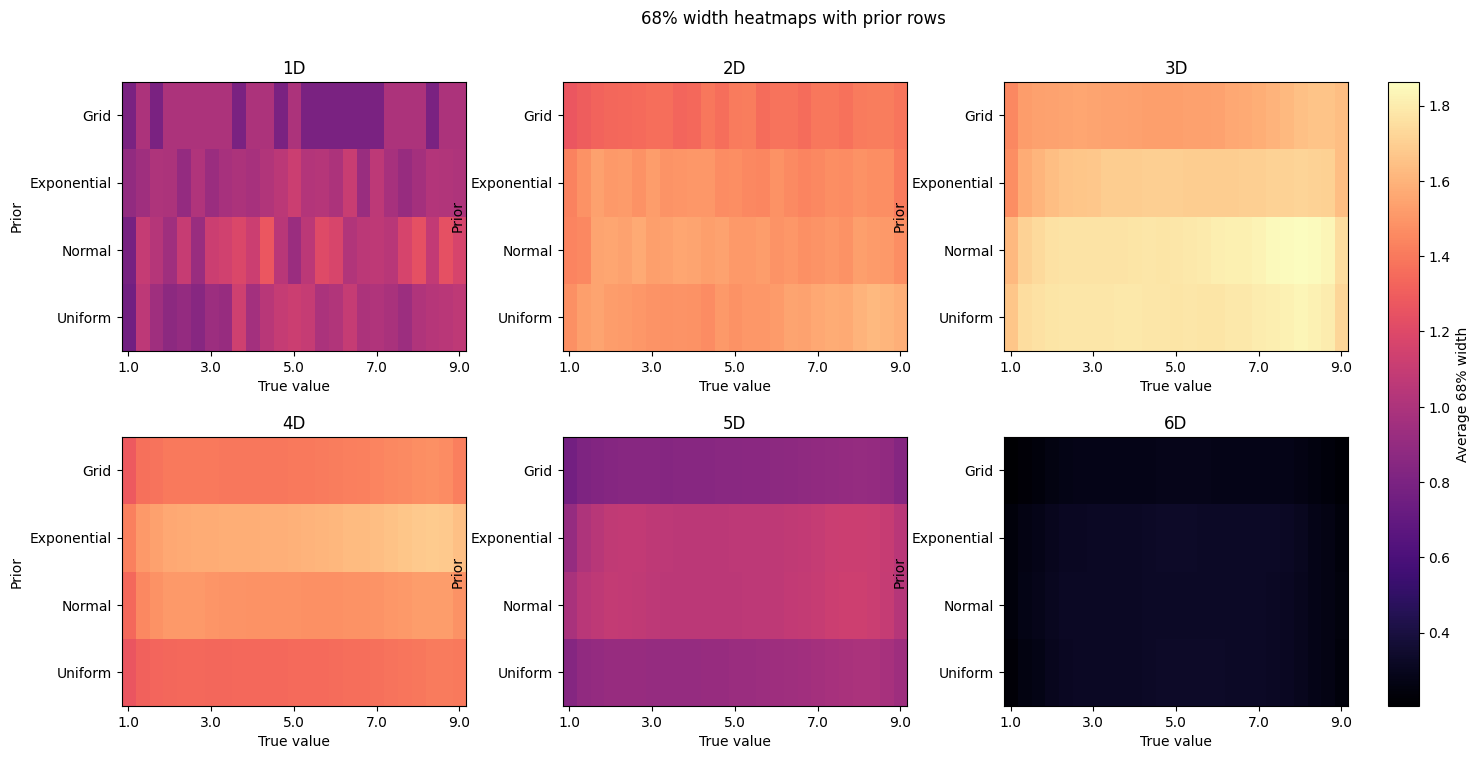

In [23]:
fig = plot_curve_heatmaps_by_dimension(curves_df, "abs_avg_bias", "Average absolute bias", cmap="magma")
fig.suptitle("Absolute bias heatmaps with prior rows", y=0.99)
save_figure(fig, "position_avg_bias_heatmap_by_dimension")
plt.show()

fig = plot_curve_heatmaps_by_dimension(curves_df, "avg_width_68", "Average 68% width", cmap="magma")
fig.suptitle("68% width heatmaps with prior rows", y=0.99)
save_figure(fig, "position_avg_width_68_heatmap_by_dimension")
plt.show()

## Raw Deep Dive (Optional)

In [24]:
if not LOAD_RAW:
    display(
        Markdown(
            f"Set `LOAD_RAW = True` to enable the compact-store deep dive. "
            f"The loader samples each config/prior combination down to at most **{RAW_MAX_POINTS_PER_CONFIG:,}** posterior settings so the full 1D-6D sweep stays usable."
        )
    )
elif raw_metadata_df.empty:
    display(Markdown("Raw loading was enabled, but no compact-store artifacts were available for the requested sweep."))
else:
    display(raw_metadata_df)

,config_id,dimension,prior,n_total_points,n_loaded_points,sampled
0,config_018,1,exponential,25,25,False
1,config_018,1,grid,25,25,False
2,config_018,1,normal,25,25,False
3,config_018,1,uniform,25,25,False
4,config_013,2,exponential,625,625,False
5,config_013,2,grid,625,625,False
6,config_013,2,normal,625,625,False
7,config_013,2,uniform,625,625,False
8,config_012,3,exponential,15625,2000,True
9,config_012,3,grid,15625,2000,True


/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecat

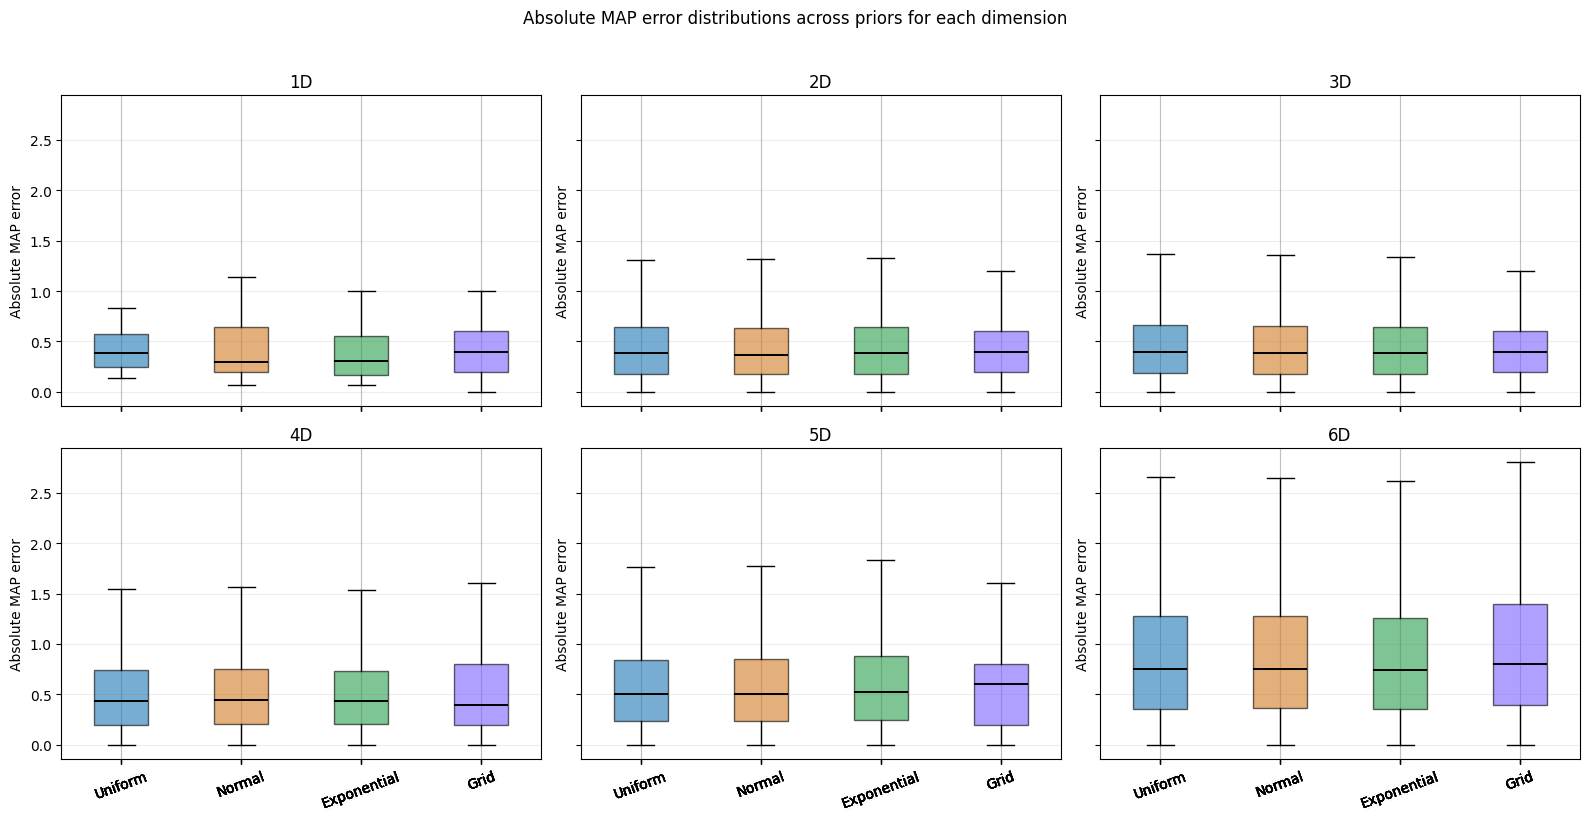

/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  boxplot = ax.boxplot(
/tmp/ipykernel_1134601/4177679796.py:633: MatplotlibDeprecat

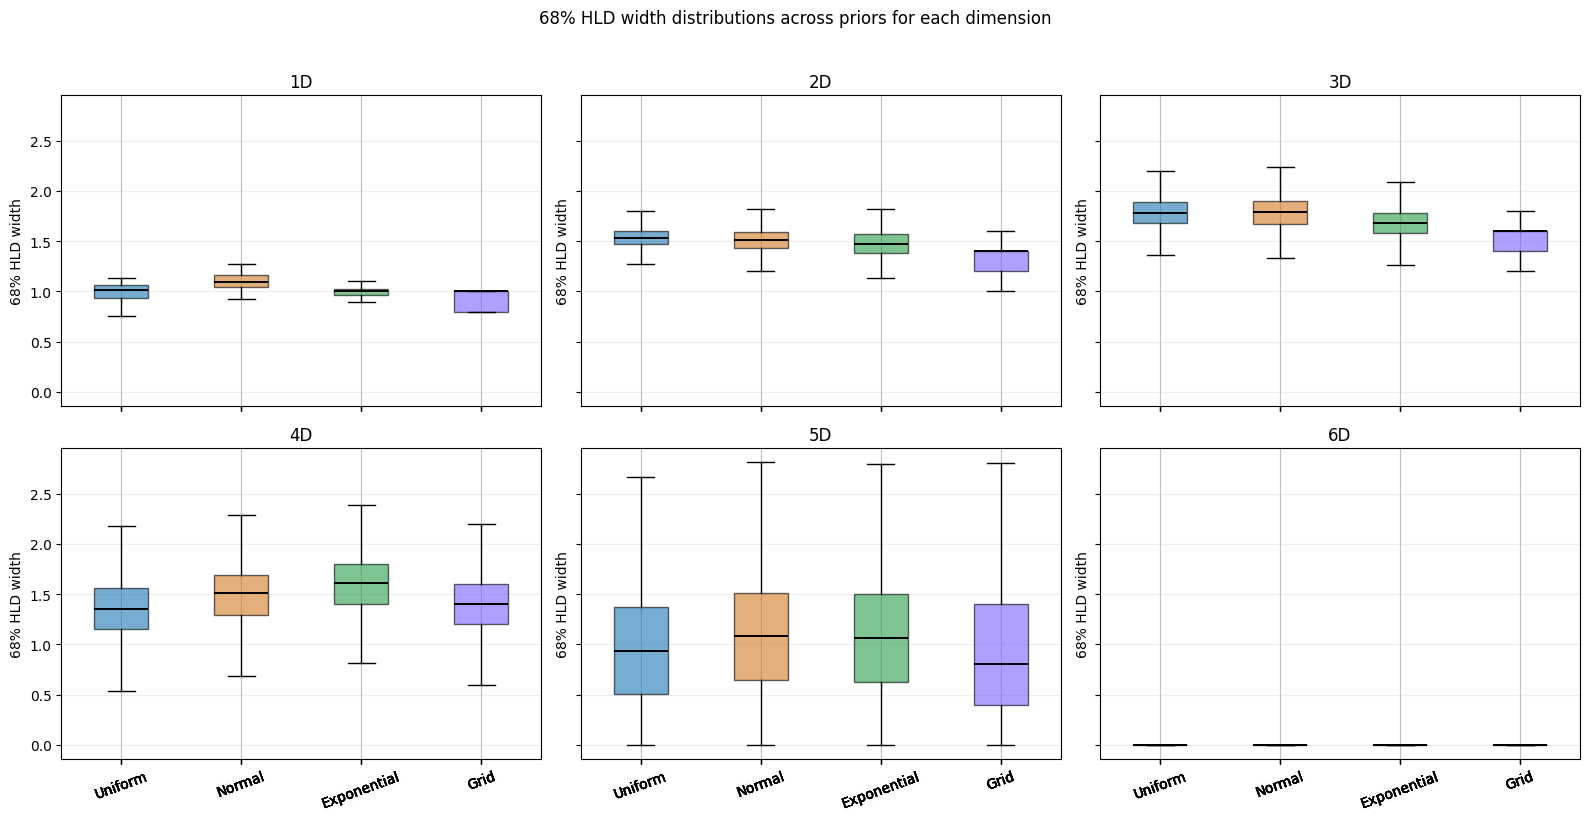

In [25]:
if LOAD_RAW and not raw_metadata_df.empty:
    interval_68_df = raw_intervals_df.loc[raw_intervals_df["interval_level"].astype(str) == "68"].copy()

    fig = plot_raw_boxplots_by_dimension(
        raw_map_df,
        "abs_map_error",
        "Absolute MAP error",
        "Absolute MAP error distributions across priors for each dimension",
    )
    save_figure(fig, "raw_map_error_boxplots_by_dimension")
    plt.show()

    fig = plot_raw_boxplots_by_dimension(
        interval_68_df,
        "width",
        "68% HLD width",
        "68% HLD width distributions across priors for each dimension",
    )
    save_figure(fig, "raw_width_68_boxplots_by_dimension")
    plt.show()

## 3D Likelihood-Ratio Corner Plots

Using `config_012` with stored true parameter `(5.0, 5.0, 5.0)` and `15` repeated observations.

Saved `Uniform` corner plot to `figs/prior_analysis/likelihood_ratio_3d_corner_uniform.pdf`.

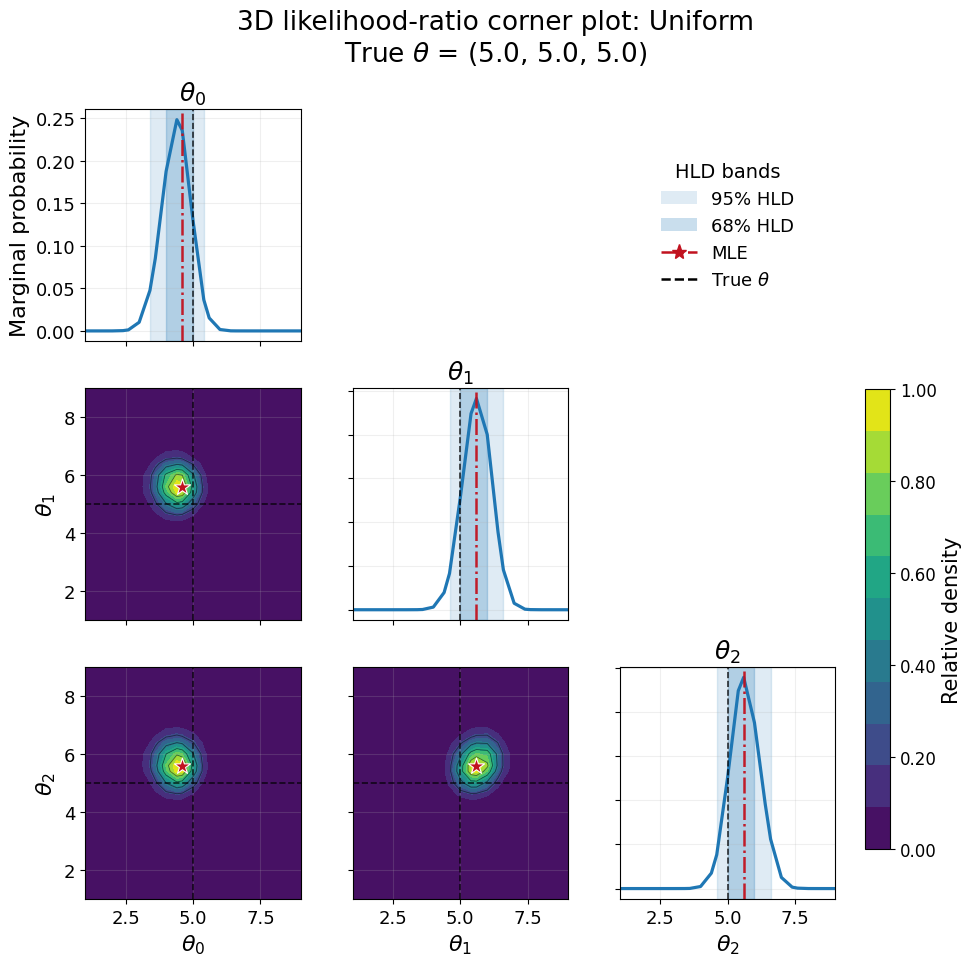

Saved `Normal` corner plot to `figs/prior_analysis/likelihood_ratio_3d_corner_normal.pdf`.

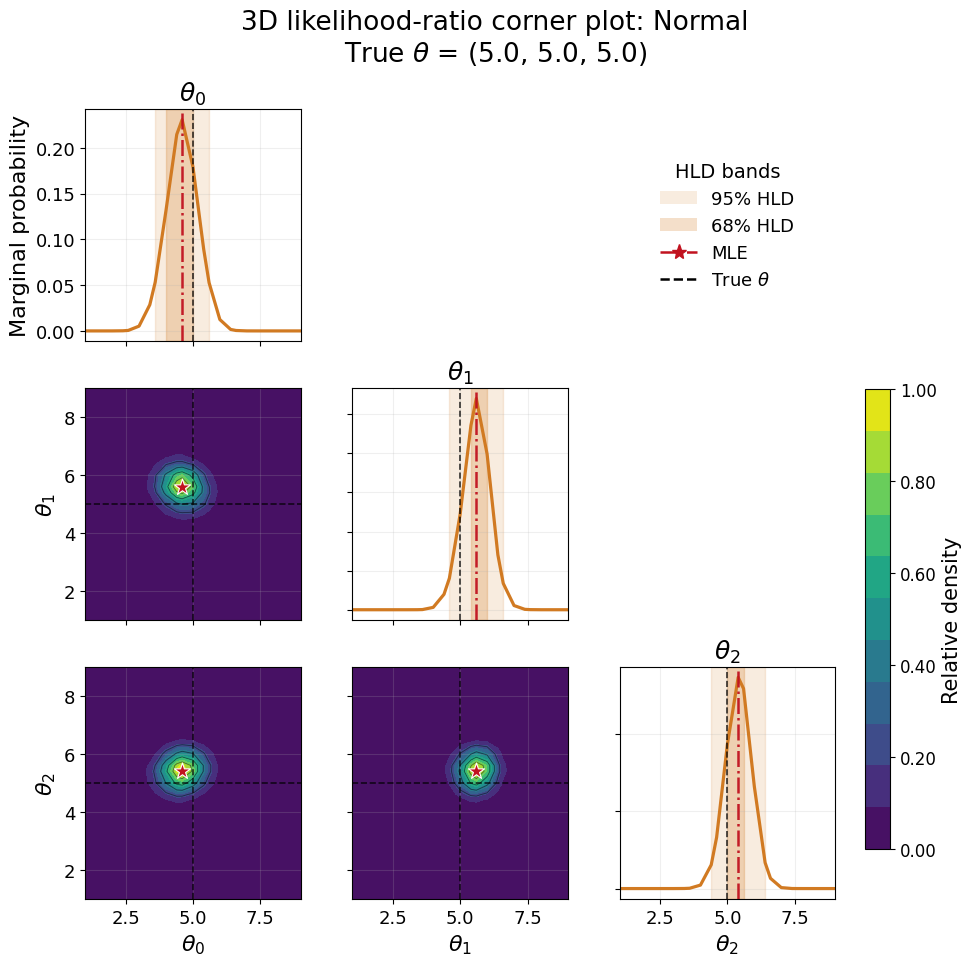

Saved `Exponential` corner plot to `figs/prior_analysis/likelihood_ratio_3d_corner_exponential.pdf`.

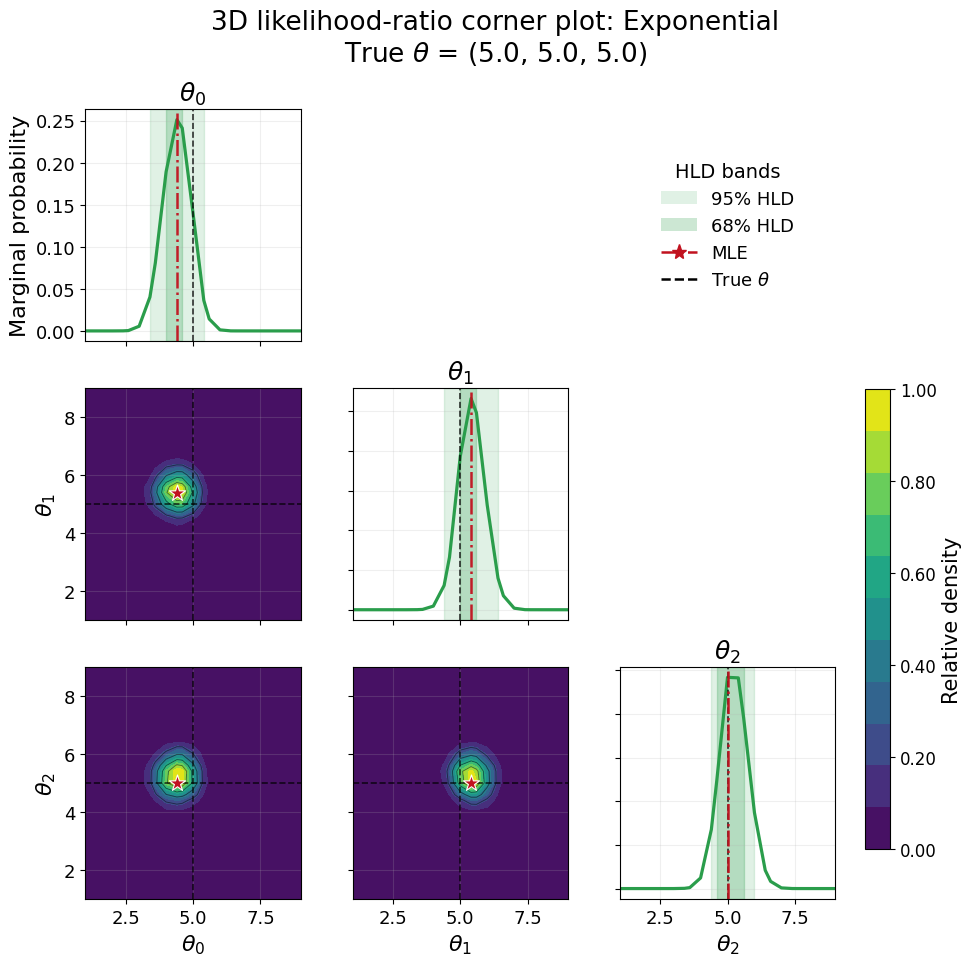

Saved `Grid` corner plot to `figs/prior_analysis/likelihood_ratio_3d_corner_grid.pdf`.

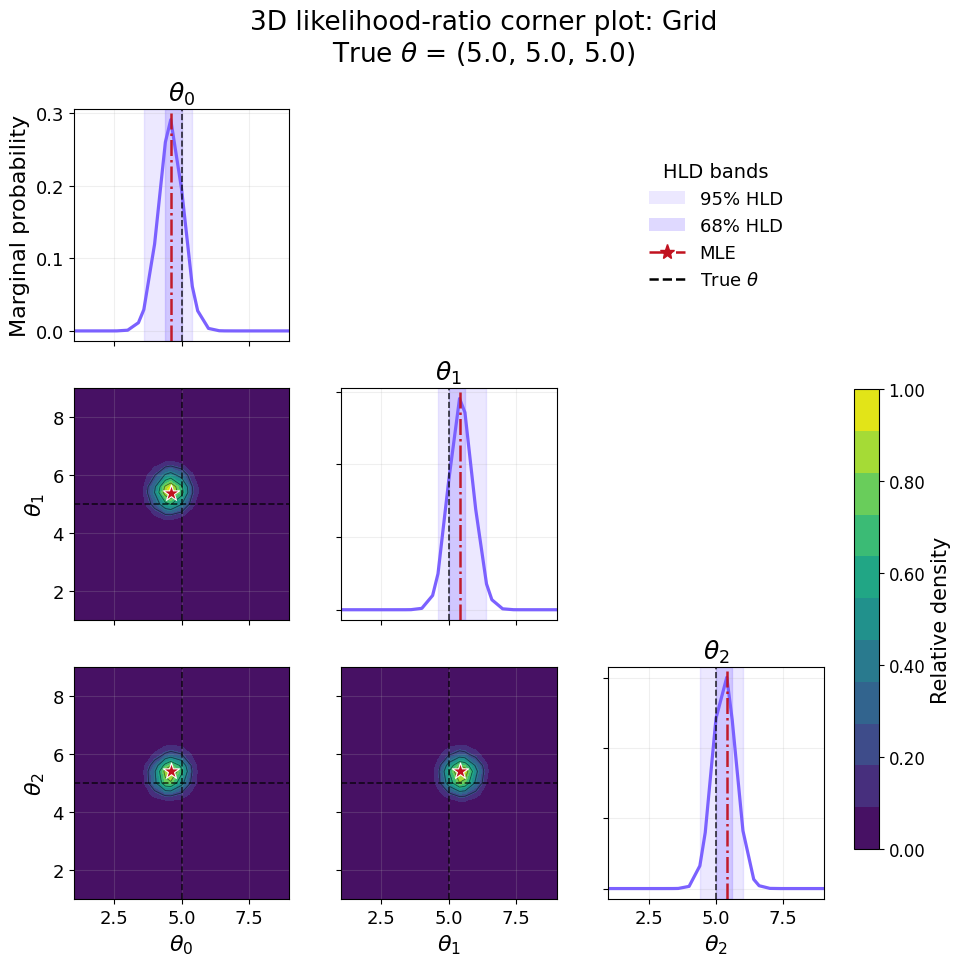

In [26]:
three_d_config_id = resolve_three_d_config_id(config_overview_df)

if three_d_config_id is None:
    display(Markdown("No resolved 3D config was present in the requested sweep."))
else:
    three_d_artifacts = load_three_d_ratio_artifacts(FIGS_ROOT, three_d_config_id)
    if three_d_artifacts is None:
        display(Markdown(f"Saved 3D ratio artifacts were not available for `{three_d_config_id}`."))
    else:
        reference_index = find_reference_parameter_index(
            three_d_artifacts["parameter_combinations"],
            THREE_D_REFERENCE_THETA,
        )
        if reference_index is None:
            display(
                Markdown(
                    f"The stored 3D grid does not contain the requested reference theta `{THREE_D_REFERENCE_THETA}`."
                )
            )
        else:
            reference_data = np.asarray(three_d_artifacts["sampled_data"][reference_index], dtype=np.float32)
            display(
                Markdown(
                    f"Using `{three_d_config_id}` with stored true parameter "
                    f"`{tuple(float(value) for value in np.asarray(THREE_D_REFERENCE_THETA, dtype=float))}` "
                    f"and `{int(reference_data.shape[0])}` repeated observations."
                )
            )

            three_d_available_priors = [
                prior
                for prior in PRIORS
                if get_three_d_prior_model_path(three_d_artifacts, prior).exists()
            ]
            if not three_d_available_priors:
                display(Markdown("No saved 3D prior models were available for corner-plot evaluation."))
            else:
                theta_shape = tuple(len(axis) for axis in three_d_artifacts["theta_axes"])
                for prior in three_d_available_priors:
                    model_path = get_three_d_prior_model_path(three_d_artifacts, prior)
                    model = load_three_d_prior_model(three_d_artifacts["config"], model_path)
                    joint_log_ratio = evaluate_three_d_joint_log_ratio_surface(
                        model,
                        reference_data,
                        three_d_artifacts["parameter_combinations"],
                        theta_shape,
                    )
                    fig = plot_three_d_likelihood_ratio_corner(
                        three_d_artifacts["theta_axes"],
                        THREE_D_REFERENCE_THETA,
                        joint_log_ratio,
                        prior,
                    )
                    output_path = save_figure(fig, f"likelihood_ratio_3d_corner_{prior}")
                    display(Markdown(f"Saved `{PRIOR_LABELS.get(prior, prior)}` corner plot to `{output_path}`."))
                    plt.show()
